# Full Method 1 Notebook (Using `main` module)

Refactored to import from the `main` directory.

In [1]:
import torch
import numpy as np
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import copy
from pathlib import Path

# Import from main
from main import (
    get_device, set_seed,
    load_participant, get_split_series,
    preprocess_eeg, preprocess_eeg_from_config,
    preprocess_emg, preprocess_emg_from_config, EMGNormalizer,
    preprocess_kinematics, preprocess_kinematics_from_config, KinNormalizer,
    extract_kt, extract_kt_raw,
    WAYEEGDataset,
    KGGTModel, build_kg_gt_from_config, CNN1dAligner,
    build_transformer_only_from_config,
    CombinedEMGLoss, build_loss_from_config,
    train_model, TrainConfig, TrainResult,
    collect_predictions, compute_metrics, EvalMetrics,
    prepare_batch_factory, save_checkpoint, load_checkpoint,
    print_gpu_info,
    compute_muscle_edge_prior,   # for edge-prior computation (follow-up step)
)

ROOT = Path(".")

In [2]:
set_seed(42)
device = get_device()
torch.backends.cudnn.benchmark = True
print(f"Device: {device}")


Device: cuda


In [3]:
CONFIG = {
    "outputs":{
        "figures_dir": "docs/figure/method1",
    },
    "data": {
        "participant": "P1",       
        "data_root": "data/way-eeg/raw",
        "cache_dir": "data/cache_main_stride500",
        # window_size=4000 @ 500 Hz = 8 s window; stride=250 = 0.5 s step
        # chunked transformer: 4000 / chunk_size=500 = 8 chunks of 500 → O(500²) not O(4000²)
        "window_size": 500,
        "stride": 500,
        "latency_shift_ms": 50.0,
        "fs_eeg": 500,                   # Hz
        "fs_emg": 4000,                  # Hz (raw); downsampled to fs_eeg after preprocess
        "fs_kin": 500,                   # Hz
        "n_eeg_channels": 32,
        "n_emg_channels": 5,
        "n_kin_raw": 36,                 # raw kin cols in hs.kin.sig
        "n_kin_features": 36             # k_t dimension after extraction
    },
    "preprocessing": {
        "eeg": {
            "bp_low": 0.5,                  # Hz, bandpass lower bound
            "bp_high": 40.0,                # Hz, bandpass upper bound
            "artifact_method": "ica_auto",  # "asr" | "ica_auto" | "ica_manual"
            "filter_order": 4,
            "notch_freq": 50.0,             # Hz, power-line
            "asr_window_ms": 500,           # ms, ASR sliding window
            "asr_std_thresh": 5.0,          # sigma, ASR rejection threshold
            "delta_low": 0.5,               # Hz, delta-band lower bound
            "delta_high": 40.0,             # Hz, delta-band upper bound
            "use_car": False,
            "use_tkeo": True,
            #"target_channels": ["FC1", "FC2", "C3", "Cz", "C4", "CP1", "CP2", "CP6"]
        },
        "emg": {
            "bp_low": 30.0,              # Hz
            "bp_high": 300.0,            # Hz
            "filter_order": 4,
            "lp_cutoff": 8.0,           # Hz, low-pass for envelope
            "downsample_factor": 8       # 4000 -> 500 Hz
        },
        "kinematics": {
            "include_velocity": True,      # if true, output includes velocity
            "include_acceleration": True,  # if true, output includes acceleration
            "drop_indices": [12, 25, 38],  # prune rho_GL from pos, vel, acc
            "velocity_method": "sg",     # 'sg' (Savitzky-Golay) | 'bw' (Butterworth diff)
            "sg_window": 11,             # SG window length (samples, must be odd)
            "sg_poly": 3,                # SG polynomial order
            "bw_cutoff": 20.0,           # LP cutoff Hz before diff (used when method='bw')
            "bw_order": 4,               # Butterworth order (used when method='bw')
            "normalize": True            # per-feature z-score over training set
        },
    },
    "model": {
        "type": "transformer_regressor",
        "transformer": {
            "n_layers": 4,
            "n_heads": 8,
            "d_model": 128,
            "d_k": 32,
            "d_v": 32,
            "ffn_dim": 512,
            "dropout": 0.2,
            # chunk_size=500 with window_size=4000 → 8 chunks of 500
            # → O(500²)=250K scores per head (not O(4000²)=16M)
            # MUST divide window_size evenly or a RuntimeWarning fires and
            # full O(T²) attention is used (catastrophically slow).
            "chunk_size": 500
        },
        "gat": {
            "n_layers": 2,
            "node_dim": 64,
            "hidden_dim": 64,
            "heads": 4,
            "dropout": 0.2,
            "use_kinematic_guidance": True,
        },
        "decoder": {
            "out_channels": 5            # predicted EMG channels
        }
    },
    "training": {
        "loss": {
            "peak_alpha":      5.0,    # 3× emphasis on EMG burst peaks vs. baseline silence
            "lambda_reg":      0.001,   # KL anchor strength: GAT edge_bias stays near prior
            "lambda_l1": 0.05,
            "lambda_grad":     0.2,
            "rest_threshold":  0.15,
            "asymmetry": 2.5,
            "use_peak_weight": True,   # set False for ablation back to standard MSE
        },
        # ── optimizer ─────────────────────────────────────────────────────
        "optimizer":   "adamw",   # 'adam' | 'adamw'
        "weight_decay": 1e-2,     # AdamW weight decay (ignored for adam)
        # ── scheduler ─────────────────────────────────────────────────────
        "scheduler":   "cosine",  # 'reduce' | 'cosine'
        # reduce-specific
        "lr_patience": 5,
        "lr_factor":   0.5,
        # cosine-specific
        "cosine_t_max":   None,   # None → use max_epochs
        "cosine_eta_min": 1e-6,
        # ── common ────────────────────────────────────────────────────────
        "loss_lambda":  1.0,      # 1.0 = plain MSE; <1.0 enables Soft-DTW (O(T²), DO NOT use at T=4000)
        "stage1_lr": 1e-3,
        "warmup_epochs": 5,
        "stage2_lr": 1e-5,
        "transformer_lr_scale": 0.1,
        # batch_size=4 with T=4000 keeps VRAM safe on GTX 1660 Ti (6 GB).
        # effective batch = batch_size * gradient_accumulation_steps = 4 * 8 = 32
        # Tune batch_size up (e.g. 8) if VRAM is available; reduce grad_accum_steps proportionally.
        "batch_size":          32,
        "gradient_accumulation_steps": 2,
        "early_stop_patience": 50,
        "grad_clip_norm":      1.0,
        "stage1_epochs":       75,
        "max_epochs":          200,
        # use_amp=True: enables FP16 mixed precision via torch.autocast + GradScaler.
        # GTX 1660 Ti (sm_75 Turing) has FP16 tensor cores → ~1.5-2x speedup.
        # Requires PyTorch >= 2.0. Set False only if you see NaN losses.
        "use_amp":             True,
        "log_memory_every":    50,
        "losocv": True,           # leave-one-subject-out cross-validation
        "checkpoint_every":     1,
        "seed":                42,
    },
    "dataset": {
        # Keep in sync with data.window_size / data.stride above
        "window_size": 500,
        "stride": 500,
        "latency_shift_ms": 0.0,
    }
}
notebook_cfg = copy.deepcopy(CONFIG)


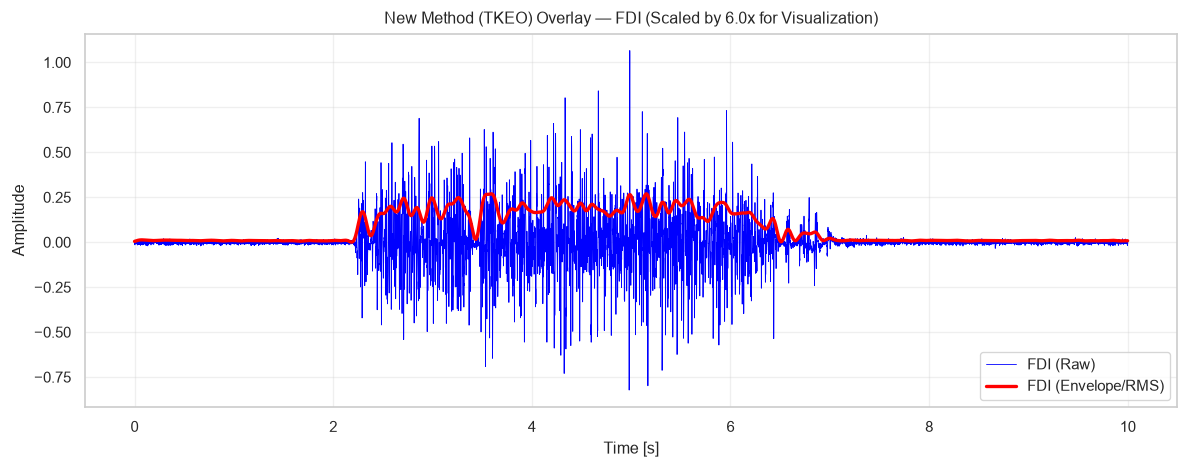

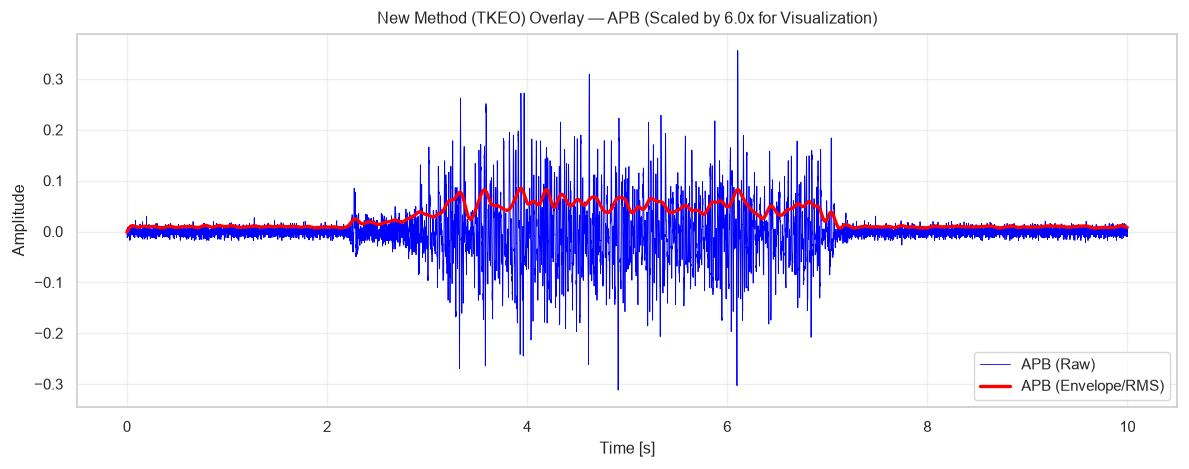

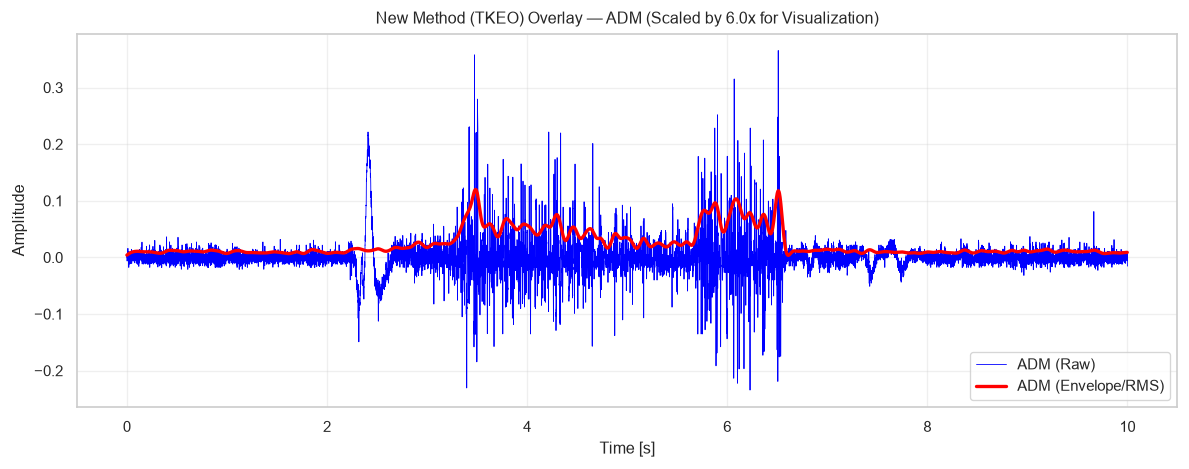

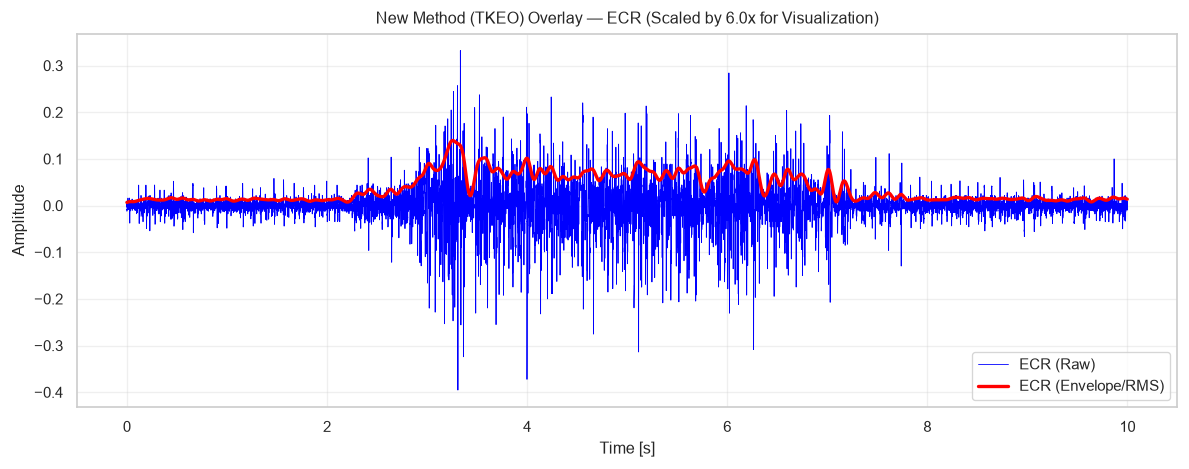

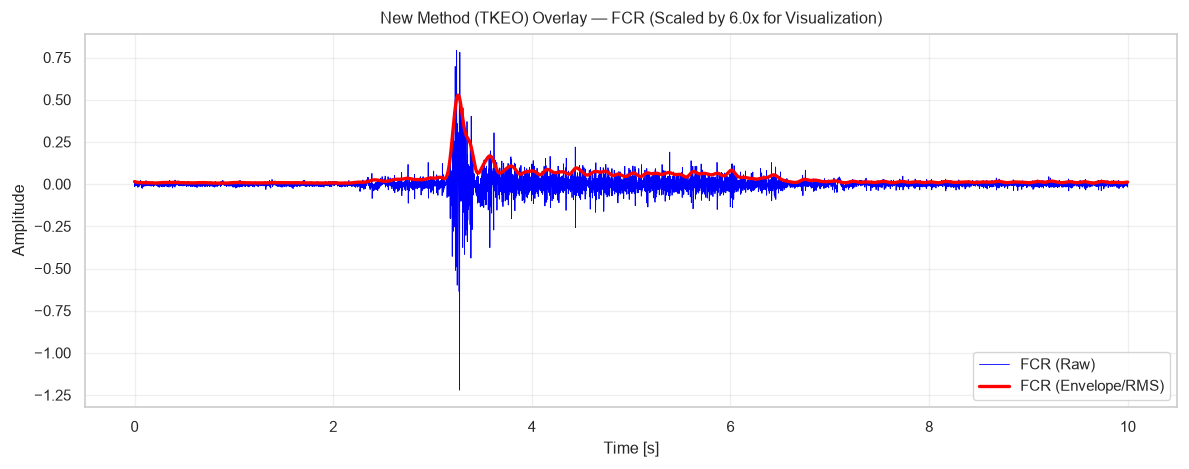

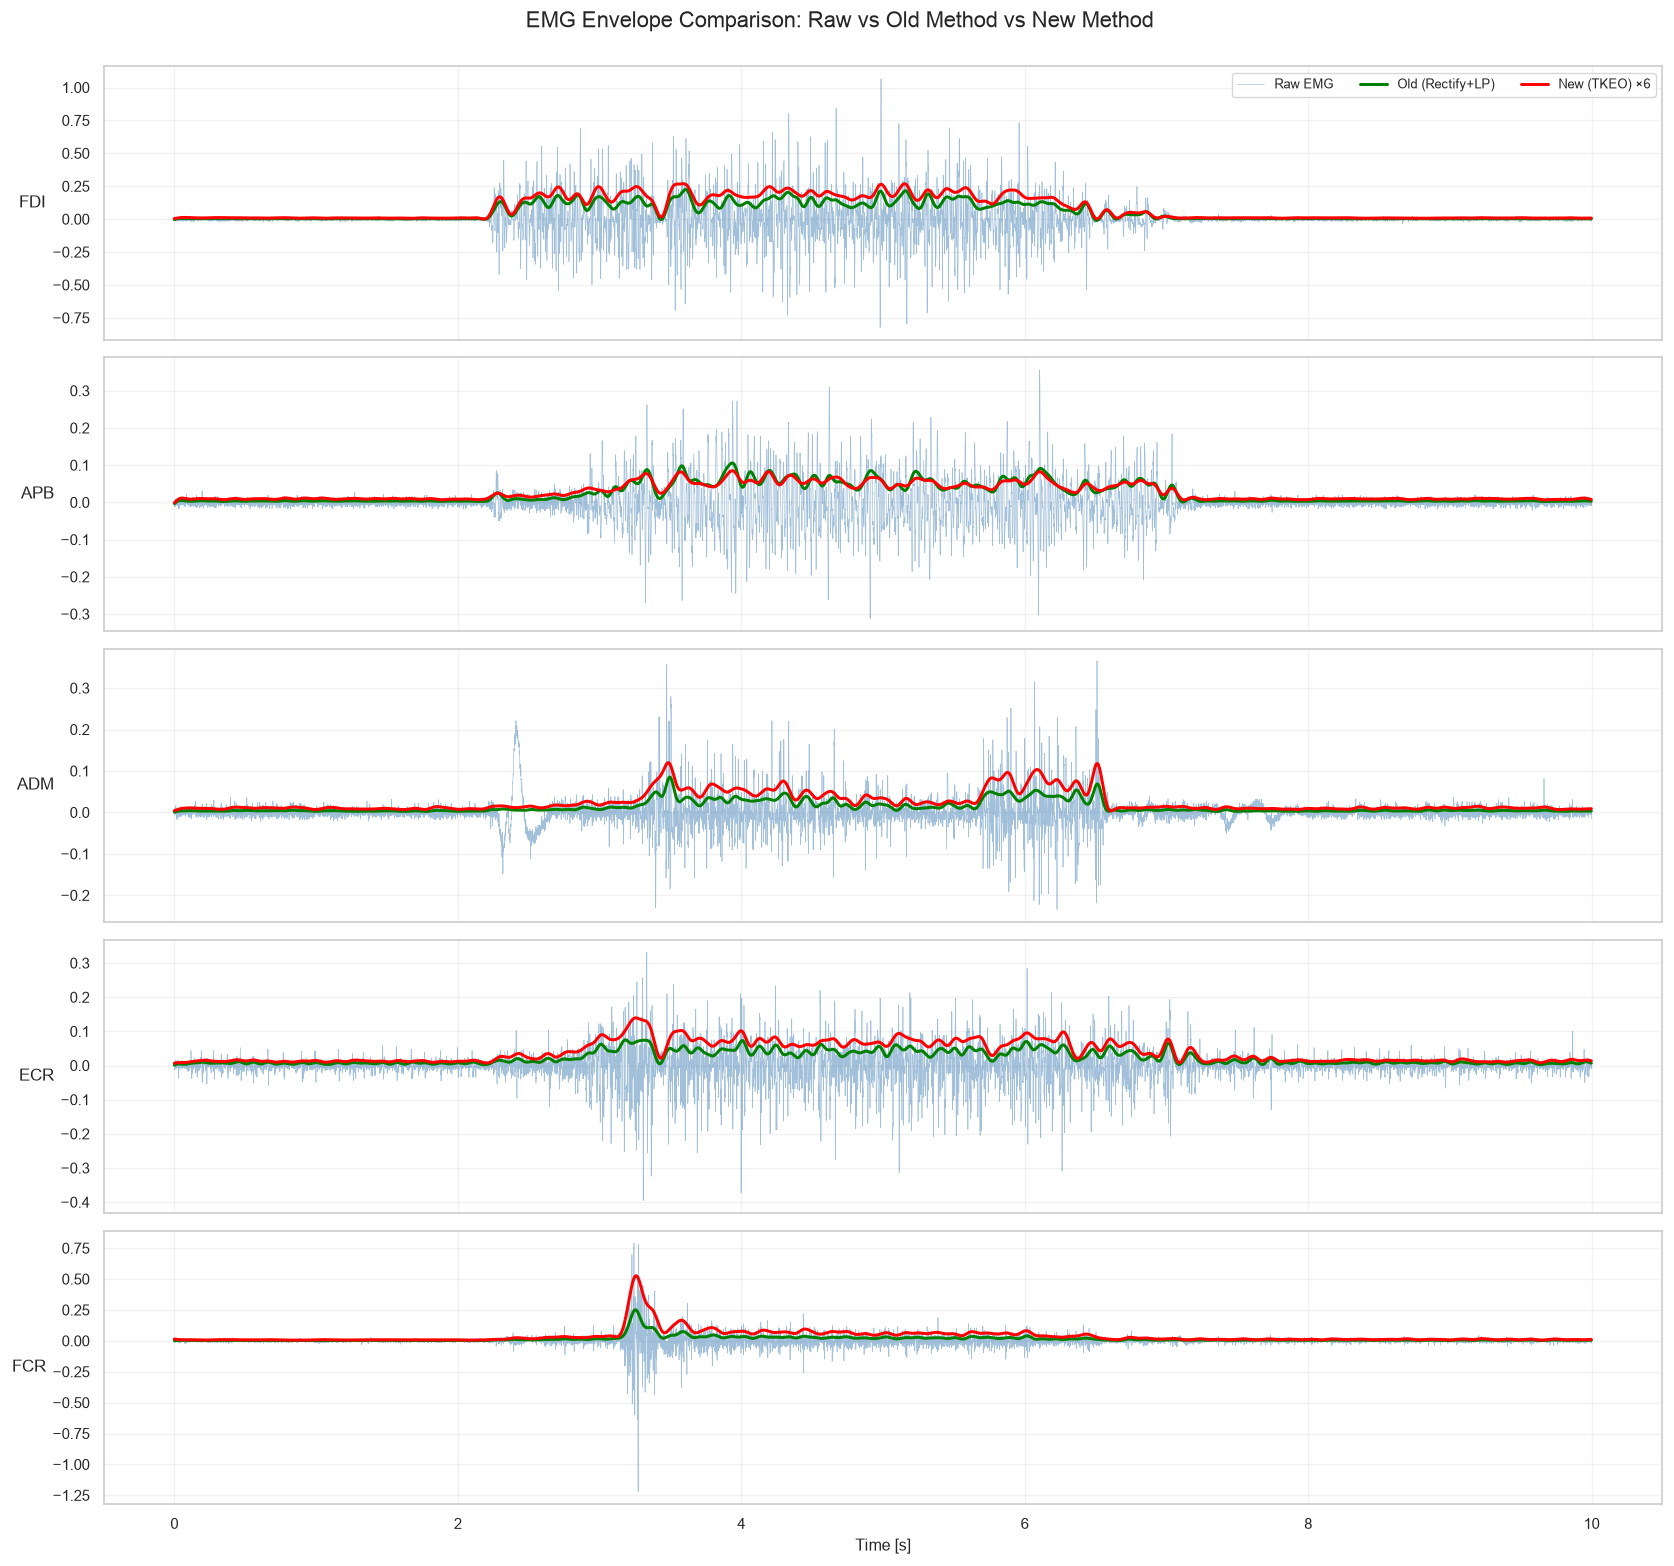

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from main.dataloader import load_hs
from main.preprocessing_emg_kin import preprocess_emg_from_config
from main.plots import plot_emg_envelope_overlay, plot_emg_method_comparison_grid

# 1. Load the continuous series dictionary
data_path = "data/way-eeg/raw/P1/HS_P1_S3.mat"  # Adjust as needed
hs_data = load_hs(data_path)
emg_raw = hs_data["emg"]
fs_raw = float(hs_data["fs_emg"])
fs_env = 500.0  # Standard downsampled rate

MUSCLE_NAMES = ["FDI", "APB", "ADM", "ECR", "FCR"]  # adjust order to match your emg columns

# 2. Process with the Old Method (Rectify + Lowpass)
cfg_old = {"bp_low": 30.0, "bp_high": 300.0, "lp_cutoff": 10.0, "use_tkeo": False}
emg_old = preprocess_emg_from_config(emg_raw, fs=fs_raw, cfg=cfg_old)

# 3. Process with the New Method (TKEO + Lowpass)
cfg_new = {"bp_low": 30.0, "bp_high": 300.0, "lp_cutoff": 8.0, "use_tkeo": True}
emg_tkeo = preprocess_emg_from_config(emg_raw, fs=fs_raw, cfg=cfg_new)

# ==========================================
# 4. Slice a window
# ==========================================
start_sec = 0
end_sec = 10

start_idx_raw, end_idx_raw = int(start_sec * fs_raw), int(end_sec * fs_raw)
start_idx_env, end_idx_env = int(start_sec * fs_env), int(end_sec * fs_env)

emg_raw_slice  = emg_raw[start_idx_raw:end_idx_raw]
emg_old_slice  = emg_old[start_idx_env:end_idx_env]
emg_tkeo_slice = emg_tkeo[start_idx_env:end_idx_env]

empirical_scale_factor = 6.0  # cosmetic only, for visual amplitude matching

# ==========================================
# 5A. Per-muscle TKEO overlay (raw + TKEO envelope), all 5 muscles
# ==========================================
emg_tkeo_scaled_for_overlay = emg_tkeo_slice * empirical_scale_factor

for ch in range(emg_raw_slice.shape[1]):
    name = MUSCLE_NAMES[ch] if ch < len(MUSCLE_NAMES) else f"Ch {ch + 1}"
    fig = plot_emg_envelope_overlay(
        raw_emg=emg_raw_slice,
        env_emg=emg_tkeo_scaled_for_overlay,
        fs_raw=fs_raw,
        fs_env=fs_env,
        channel_idx=ch,
        channel_name=name,
        title=f"New Method (TKEO) Overlay — {name} "
              f"(Scaled by {empirical_scale_factor}x for Visualization)",
    )
    plt.show()

# ==========================================
# 5B. Combined comparison grid: Raw + Old + New, all 5 muscles in one figure
# ==========================================
fig_combined = plot_emg_method_comparison_grid(
    raw_emg=emg_raw_slice,
    env_old=emg_old_slice,
    env_new=emg_tkeo_slice,
    fs_raw=fs_raw,
    fs_env=fs_env,
    muscle_names=MUSCLE_NAMES,
    new_method_label="TKEO",
    old_method_label="Rectify+LP",
    new_scale_factor=empirical_scale_factor,
    start_sec=start_sec,
)
plt.show()

In [5]:
def make_preprocess_fn(cfg):
    eeg_cfg = cfg["preprocessing"]["eeg"]
    emg_cfg = cfg["preprocessing"]["emg"]
    kin_cfg = cfg["preprocessing"]["kinematics"]
    def preprocess_fn(series):
        series = dict(series)
        series["eeg"] = preprocess_eeg_from_config(
            series["eeg"],
            float(series["fs_eeg"]),
            eeg_cfg,
            channel_names=series.get("eeg_names"),
        )
        series["emg"] = preprocess_emg_from_config(
            series["emg"],
            float(series["fs_emg"]),
            emg_cfg,
        )
        series["kin"] = preprocess_kinematics_from_config(                                           
              series["kin"],                                                                           
              float(series["fs_kin"]),                                                                 
              kin_cfg,                                                                                 
        ) 
        return series

    return preprocess_fn


def resolve_participants(participant_spec):
    """Resolve participant spec to a list of int IDs.
    
    Accepts:
      "all"        -> [1, 2, ..., 12]
      "P3"         -> [3]
      3            -> [3]
      [1, 2, 3]   -> [1, 2, 3]
      ["P1", "P3"] -> [1, 3]
    """
    ALL_PARTICIPANTS = list(range(1, 13))
    if participant_spec == "all":
        return ALL_PARTICIPANTS
    if isinstance(participant_spec, (list, tuple)):
        return [int(str(p).replace("P", "")) for p in participant_spec]
    # single string like "P2" or int like 2
    return [int(str(participant_spec).replace("P", ""))]


def build_dataset_split(cfg, participants=None, split="train", root_dir=ROOT):
    """Build WAYEEGDataset for the given split.
    
    participants: list of int IDs, or None (uses cfg["data"]["participant"]).
    split: "train" | "val" | "test" | "all" | "stability"
    """
    data_cfg = cfg["data"]
    if participants is None:
        participants = resolve_participants(data_cfg["participant"])
    return WAYEEGDataset(
        data_dir=root_dir / data_cfg["data_root"],
        participants=participants,
        split=split,
        window_size=cfg["dataset"]["window_size"],
        stride=cfg["dataset"]["stride"],
        latency_shift_ms=cfg["dataset"].get("latency_shift_ms", 0.0),
        preprocess_fn=make_preprocess_fn(cfg),
        cache_dir=root_dir / data_cfg["cache_dir"]
    )


In [6]:
# ============================================================================
# Participant / LOSOCV Setup
# ============================================================================
# Supported values for notebook_cfg["data"]["participant"]:
#   "all"      → LOSOCV over all 12 subjects
#   [1,3,5]    → LOSOCV over a specific list
#   "P2" or 2  → Single-subject training (uses train/val/test series split)
#
# LOSOCV val strategy (Option 2 — scientifically clean):
#   For each fold where p_test is the held-out subject:
#     - val_participant  = last subject in the train list (rotates each fold)
#     - train on remaining N-2 subjects (all their series)
#     - val   on val_participant         (all their series) → early stopping
#     - test  on p_test                  (all their series) → final metric
#   The test subject's data NEVER influences any training decision.
# ─────────────────────────────────────────────────────────────────────────────

participant_spec = notebook_cfg["data"]["participant"]
participant_list = resolve_participants(participant_spec)
is_losocv = isinstance(participant_spec, (list, tuple)) or participant_spec == "all"

if is_losocv:
    print(f"LOSOCV mode: {len(participant_list)} participants -> {participant_list}")
    # Initialise first fold
    p_test = participant_list[0]
    # Use the LAST training subject as val (it rotates each fold naturally)
    _train_candidates = [p for p in participant_list if p != p_test]
    val_participant    = _train_candidates[-1]          # held-out from training for early stopping
    train_participants = _train_candidates[:-1]          # N-2 subjects for actual training
    test_participants  = [p_test]
    split_train = split_val = split_test = "all"
    subject_str = f"LOSO_P{p_test}"
else:
    p_id = participant_list[0]
    train_participants = [p_id]
    val_participant    = p_id          # same subject, different series
    test_participants  = [p_id]
    split_train, split_val, split_test = "train", "val", "test"
    subject_str = f"P{p_id}"

print(f"Active subject string : {subject_str}")
print(f"Train participants    : {train_participants}  ({len(train_participants)} subjects)")
print(f"Val  participant      : [{val_participant}]  (early-stopping signal — clean from test)")
print(f"Test participants     : {test_participants}   (final metric — never seen during training)")
print(f"Dataset splits        : train={split_train!r}  val={split_val!r}  test={split_test!r}")


Active subject string : P1
Train participants    : [1]  (1 subjects)
Val  participant      : [1]  (early-stopping signal — clean from test)
Test participants     : [1]   (final metric — never seen during training)
Dataset splits        : train='train'  val='val'  test='test'


In [7]:
# ============================================================================
# [OPTIONAL] Automatic LOSOCV — Run ALL Folds Unattended
# ============================================================================
# Run this cell to automatically iterate over all LOSOCV folds.
# Only runs when is_losocv = True (participant = "all" or a list).
#
# Val strategy (Option 2 — scientifically clean):
#   val_participant = last element of each fold's train list
#   → early stopping never touches the test subject's data
#
# Checkpoints saved to: outputs/checkpoints_main_stage1|2/LOSO_P{N}/
# Figures saved to:     outputs/figures/
# Summary CSV saved to: outputs/losocv_results.csv
#
# Note: Variables from the LAST fold are saved to global scope
# so that downstream individual plotting/evaluation cells can run seamlessly!
# ─────────────────────────────────────────────────────────────────────────────
import copy, gc, time, os
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from torch.utils.data import DataLoader
from main import (
    build_transformer_only_from_config, build_kg_gt_from_config,
    train_model, TrainConfig,
    collect_predictions, compute_metrics, load_checkpoint,
    compute_muscle_edge_prior, build_loss_from_config,
)
from main.plots import plot_interpretability_triptych, plot_kin_skip_over_time

if not is_losocv:
    print("Single-subject mode — skipping auto LOSOCV loop.  Run cells below instead.")
else:
    EMG_NAMES = ["FDI", "APB", "ADM", "ECR", "FCR"]
    cv_rows = []
    os.makedirs("outputs/figures", exist_ok=True)

    for _fold_idx, _p_test in enumerate(participant_list):
        _t_fold = time.time()

        # ── Option 2: one training subject held-out for val ───────────────────
        _train_candidates = [p for p in participant_list if p != _p_test]
        _val_p     = _train_candidates[-1]       # rotates naturally each fold
        _train_ps  = _train_candidates[:-1]      # N-2 subjects
        _test_ps   = [_p_test]
        _subj      = f"LOSO_P{_p_test}"

        print(f"\n{'='*65}")
        print(f"  FOLD {_fold_idx+1}/{len(participant_list)}")
        print(f"  Train  : {_train_ps}  ({len(_train_ps)} subjects)")
        print(f"  Val    : [{_val_p}]  (early-stopping only)")
        print(f"  Test   : [{_p_test}]  (final metric — never seen during training)")
        print(f"{'='*65}")

        # ── Datasets ──────────────────────────────────────────────────────────
        _train_ds = build_dataset_split(notebook_cfg, participants=_train_ps, split="all")
        _val_ds   = build_dataset_split(notebook_cfg, participants=[_val_p],  split="all")
        _test_ds  = build_dataset_split(notebook_cfg, participants=_test_ps,  split="all")

        # ── Normalization stats from training fold only ────────────────────────
        def _unique_arrays(ds):
            seen, kins, emgs = set(), [], []
            for ea, ka, ma, _ in ds._windows:
                k = id(ea)
                if k not in seen:
                    seen.add(k); kins.append(ka); emgs.append(ma)
            return kins, emgs

        _tr_kins, _tr_emgs = _unique_arrays(_train_ds)
        _kin_all = np.concatenate(_tr_kins, axis=0)
        _emg_all = np.concatenate(_tr_emgs, axis=0)

        _emg_mean = torch.tensor(_emg_all.mean(0), dtype=torch.float32, device=device)
        _emg_std  = torch.clamp(torch.tensor(_emg_all.std(0),  dtype=torch.float32, device=device), min=1e-6)
        _kin_mean = torch.tensor(_kin_all.mean(0), dtype=torch.float32, device=device)
        _kin_std  = torch.clamp(torch.tensor(_kin_all.std(0),  dtype=torch.float32, device=device), min=1e-6)

        # ── Edge prior + loss ─────────────────────────────────────────────────
        _prior_np   = compute_muscle_edge_prior(_tr_emgs)
        _edge_prior = torch.from_numpy(_prior_np)
        _loss_fn    = build_loss_from_config(notebook_cfg["training"])

        # ── prepare_batch ─────────────────────────────────────────────────────
        _drop_idx = notebook_cfg["preprocessing"]["kinematics"]["drop_indices"]
        def _make_pb(em, es, km, ks, dev, drop_idx):
            def _pb(eeg, kin, emg):
                eeg = eeg.to(dev, non_blocking=True)
                kin = kin.to(dev, non_blocking=True)
                emg = emg.to(dev, non_blocking=True)
                kn  = (kin - km) / ks
                if drop_idx:
                    keep = [i for i in range(kn.shape[-1]) if i not in drop_idx]
                    kn   = kn[..., keep]
                return {"eeg": eeg, "kin": kn}, (emg - em) / es
            return _pb
        _pb = _make_pb(_emg_mean, _emg_std, _kin_mean, _kin_std, device, _drop_idx)

        # ── Dims ──────────────────────────────────────────────────────────────
        _s_eeg, _s_kin, _s_emg = _train_ds[0]
        _bi, _ = _pb(_s_eeg.unsqueeze(0), _s_kin.unsqueeze(0), _s_emg.unsqueeze(0))
        _eeg_dim = _s_eeg.shape[-1]
        _kin_dim = _bi["kin"].shape[-1]

        # ── DataLoaders ───────────────────────────────────────────────────────
        _bs = notebook_cfg["training"]["batch_size"]
        _tr_loader  = DataLoader(_train_ds, batch_size=_bs, shuffle=True,  drop_last=True,  pin_memory=True, num_workers=0)
        _val_loader = DataLoader(_val_ds,   batch_size=_bs, shuffle=False, pin_memory=True, num_workers=0)
        _te_loader  = DataLoader(_test_ds,  batch_size=_bs, shuffle=False, pin_memory=True, num_workers=0)

        # ── STAGE 1: Transformer pre-training ────────────────────────────────
        print(f"  Stage 1: Transformer pre-training ({notebook_cfg['training']['stage1_epochs']} epochs) ...")
        _s1 = build_transformer_only_from_config(notebook_cfg, input_dim=_eeg_dim).to(device)
        _s1_cfg = TrainConfig.from_config(
            notebook_cfg["training"],
            max_epochs=notebook_cfg["training"]["stage1_epochs"],
            lr=notebook_cfg["training"]["stage1_lr"],
        )
        _s1_cfg.checkpoint_dir = notebook_cfg["training"].get("checkpoint_dir", "outputs/checkpoints_main") + f"_stage1/{_subj}"
        _r1 = train_model(
            model=_s1, train_loader=_tr_loader, val_loader=_val_loader,
            prepare_batch=_pb, loss_fn=_loss_fn, device=device, cfg=_s1_cfg, resume=True,
        )

        # ── STAGE 2: Full KG-GT with frozen transformer ───────────────────────
        print(f"  Stage 2: GAT fine-tuning ({notebook_cfg['training']['max_epochs']} epochs) ...")
        _s2 = build_kg_gt_from_config(
            notebook_cfg, input_dim=_eeg_dim, kin_dim=_kin_dim, edge_prior=_edge_prior
        ).to(device)

        if _r1.best_state is not None:
            _filtered = {k: v for k, v in _r1.best_state.items()
                         if k.startswith("encoder.") or k.startswith("node_projection.")}
            _s2.load_state_dict(_filtered, strict=False)

        for _p in _s2.parameters():                     _p.requires_grad = False
        for _p in _s2.gat.parameters():                  _p.requires_grad = True
        for _p in _s2.decoder.parameters():              _p.requires_grad = True
        if hasattr(_s2, "kin_skip_proj") and _s2.kin_skip_proj is not None:
            for _p in _s2.kin_skip_proj.parameters():   _p.requires_grad = True
        for _p in _s2.encoder.layers[-1].parameters():  _p.requires_grad = True
        for _p in _s2.node_projection.parameters():     _p.requires_grad = True

        _s2_cfg = TrainConfig.from_config(
            notebook_cfg["training"],
            max_epochs=notebook_cfg["training"]["max_epochs"],
            lr=notebook_cfg["training"]["stage2_lr"],
        )
        _s2_cfg.checkpoint_dir = notebook_cfg["training"].get("checkpoint_dir", "outputs/checkpoints_main") + f"_stage2/{_subj}"
        _r2 = train_model(
            model=_s2, train_loader=_tr_loader, val_loader=_val_loader,
            prepare_batch=_pb, loss_fn=_loss_fn, device=device, cfg=_s2_cfg, resume=True,
        )

        # ── Evaluation on held-out TEST subject ───────────────────────────────
        _ckpt = notebook_cfg["training"].get("checkpoint_dir", "outputs/checkpoints_main") + f"_stage2/{_subj}/best.pt"
        _bm   = copy.deepcopy(_s2)
        load_checkpoint(_ckpt, _bm, device)
        _bm.eval()

        _P, _Y = collect_predictions(
            _bm, _te_loader, _pb, device,
            n_channels=len(EMG_NAMES), use_amp=notebook_cfg["training"]["use_amp"],
        )
        _m = compute_metrics(_P, _Y, channel_names=EMG_NAMES)
        print(f"\n  [P{_p_test} TEST RESULTS]")
        print(_m.as_table())

        cv_rows.append({
            "Fold":         _subj,
            "val_subject":  f"P{_val_p}",
            "train_n":      len(_train_ps),
            **{f"RMSE_{n}":    float(_m.rmse[i])    for i, n in enumerate(EMG_NAMES)},
            **{f"nRMSE_{n}":   float(_m.nrmse[i])   for i, n in enumerate(EMG_NAMES)},
            **{f"MAE_{n}":     float(_m.mae[i])     for i, n in enumerate(EMG_NAMES)},
            **{f"Pearson_{n}": float(_m.pearson[i])  for i, n in enumerate(EMG_NAMES)},
            **{f"R2_{n}":      float(_m.r2[i])       for i, n in enumerate(EMG_NAMES)},
            **{f"VAF_{n}":     float(_m.vaf[i])      for i, n in enumerate(EMG_NAMES)},
            "RMSE_mean":    float(_m.rmse.mean()),
            "nRMSE_mean":   float(_m.nrmse.mean()),
            "MAE_mean":     float(_m.mae.mean()),
            "Pearson_mean": float(_m.pearson.mean()),
            "R2_mean":      float(_m.r2.mean()),
            "VAF_mean":     float(_m.vaf.mean()),
        })

        # ── Save Plots for this fold ──────────────────────────────────────────
        # 1. Training History (Stage 1 & Stage 2)
        fig_hist, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor="white")
        
        # Stage 1 curves
        s1_epochs = np.arange(1, len(_r1.history["train"]) + 1)
        ax1 = axes[0]
        ax1.plot(s1_epochs, _r1.history["train"], label="Stage 1 Train", color="#4C9BE8", linewidth=1.5)
        ax1.plot(s1_epochs, _r1.history["val"],   label="Stage 1 Val",   color="#E87B4C", linewidth=1.5)
        ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title(f"Stage 1 (Pretraining) — {_subj}")
        ax1.legend(); ax1.grid(alpha=0.3)

        # Stage 2 curves
        s2_epochs = np.arange(1, len(_r2.history["train"]) + 1)
        ax2 = axes[1]
        ax2.plot(s2_epochs, _r2.history["train"], label="Stage 2 Train", color="#2ECC71", linewidth=1.5)
        ax2.plot(s2_epochs, _r2.history["val"],   label="Stage 2 Val",   color="#E74C3C", linewidth=1.5)
        ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss"); ax2.set_title(f"Stage 2 (GAT Finetuning) — {_subj}")
        ax2.legend(); ax2.grid(alpha=0.3)

        plt.suptitle(f"2-Stage Training History — {_subj}", fontweight="bold")
        plt.tight_layout()
        plt.savefig(f"outputs/figures/history_2stage_{_subj}.png", dpi=300)
        plt.close(fig_hist)

        # 2. Interpretability Triptych (Continuous Test Window)
        fs = notebook_cfg["data"].get("fs_eeg", 500.0)
        eeg_full, kin_full, emg_full, block_start_idx = _test_ds._windows[0]
        start_idx = block_start_idx + int(0.0 * fs)
        end_idx   = block_start_idx + int(10.0 * fs)

        raw_eeg = torch.tensor(eeg_full[start_idx : end_idx])
        raw_kin = torch.tensor(kin_full[start_idx : end_idx])
        raw_emg = torch.tensor(emg_full[start_idx : end_idx])

        model_inputs, emg_norm = _pb(raw_eeg.unsqueeze(0), raw_kin.unsqueeze(0), raw_emg.unsqueeze(0))
        eeg_b = model_inputs["eeg"]
        kin_b = model_inputs["kin"]
        emg_b = emg_norm

        _bm.eval()
        for layer in _bm.encoder.layers:
            layer.mhsa.attention_temperature = 4.0

        with torch.no_grad():
            pred_b = _bm(eeg_b, kin_b)

        pred_np = pred_b[0].cpu().float().numpy()   
        true_np = emg_b[0].cpu().float().numpy()    

        emg_mean_np = _emg_mean.cpu().numpy()
        emg_std_np  = _emg_std.cpu().numpy()
        pred_np = pred_np * emg_std_np + emg_mean_np
        true_np = true_np * emg_std_np + emg_mean_np

        eeg_attn_np = _bm.encoder.layers[-1].mhsa.last_attn_weights[0].cpu().float().numpy()
        eeg_attn_np = gaussian_filter1d(eeg_attn_np, sigma=3.0, axis=-1)

        if hasattr(_bm.gat, "last_kin_edge_bias"):
            kin_edge_np = _bm.gat.last_kin_edge_bias[0].cpu().float().numpy()
        else:
            kin_edge_np = np.zeros((pred_np.shape[0], 4, len(EMG_NAMES), len(EMG_NAMES)))

        KIN_FEATURE_NAMES = [          
            "p_wrist_x", "p_wrist_y", "p_wrist_z",
            "p_index_x", "p_index_y", "p_index_z",
            "p_thumb_x", "p_thumb_y", "p_thumb_z",
            "d_grip",    "F_L",        "F_G",    
        ]

        fig_triptych = plot_interpretability_triptych(
            pred=pred_np,
            target=true_np,
            eeg_attn=eeg_attn_np,
            kin_edge_bias=kin_edge_np,
            muscle_names=EMG_NAMES,
            kin_feature_names=KIN_FEATURE_NAMES,
            fs=fs,
            smooth_hz=5.0,
            cfg=notebook_cfg,
        )
        plt.savefig(f"outputs/figures/interpretability_{_subj}.png", dpi=300)
        plt.close(fig_triptych)

        # 3. Kinematic Skip Highway Diagnostic Plot
        fig_skip = plot_kin_skip_over_time(
            model=_bm,
            eeg_window=eeg_b,
            kin_window=kin_b,
            emg_target=true_np,
            emg_mean=_emg_mean,
            emg_std=_emg_std,
            smooth_hz=5.0,
            emg_names=EMG_NAMES,
            fs=fs,
            cfg=notebook_cfg,
        )
        plt.savefig(f"outputs/figures/kin_skip_{_subj}.png", dpi=300)
        plt.close(fig_skip)

        # Save last fold variables to global scope for downstream single-subject cells
        if _fold_idx == len(participant_list) - 1:
            stage1_model = _s1
            model = _s2
            best_model = _bm
            train_loader = _tr_loader
            val_loader = _val_loader
            test_loader = _te_loader
            train_ds = _train_ds
            val_ds = _val_ds
            test_ds = _test_ds
            prepare_batch = _pb
            emg_mean = _emg_mean
            emg_std = _emg_std
            kin_mean = _kin_mean
            kin_std = _kin_std
            result_stage1 = _r1
            result_stage2 = _r2
            subject_str = _subj
            edge_prior = _edge_prior
            true_eeg_dim = _eeg_dim
            true_kin_dim = _kin_dim
            print("\n[!] Saved last fold variables to global scope for downstream analysis cells.")
        else:
            del _s1, _s2, _bm, _train_ds, _val_ds, _test_ds
            del _tr_loader, _val_loader, _te_loader
            torch.cuda.empty_cache(); gc.collect()

        print(f"  Fold {_fold_idx+1} done in {(time.time()-_t_fold)/60:.1f} min")

    # ── Cross-Validation Summary ──────────────────────────────────────────────
    cv_df = pd.DataFrame(cv_rows)
    _num_cols = cv_df.select_dtypes("number").columns
    mean_row  = cv_df[_num_cols].mean().to_dict()
    mean_row["Fold"] = "CV MEAN"; mean_row["val_subject"] = "—"
    cv_df = pd.concat([cv_df, pd.DataFrame([mean_row])], ignore_index=True)

    print("\n" + "="*65)
    print("  LEAVE-ONE-SUBJECT-OUT CROSS-VALIDATION SUMMARY")
    print("  Val strategy: Option 2 (training-subject held out for early stopping)")
    print("="*65)
    summary_cols = ["Fold","val_subject","train_n","RMSE_mean","nRMSE_mean","Pearson_mean","VAF_mean"]
    print(cv_df[summary_cols].to_string(index=False))
    print("="*65)

    os.makedirs("outputs", exist_ok=True)
    cv_df.to_csv("outputs/losocv_results.csv", index=False)
    print("Full results exported to: outputs/losocv_results.csv")
    print("DataFrame available as: cv_df")


Single-subject mode — skipping auto LOSOCV loop.  Run cells below instead.


In [8]:
# ============================================================================
# Build Datasets  (re-run this cell for each LOSOCV fold)
# ============================================================================
train_ds = build_dataset_split(notebook_cfg, participants=train_participants, split=split_train)
val_ds   = build_dataset_split(notebook_cfg, participants=test_participants,  split=split_val)
test_ds  = build_dataset_split(notebook_cfg, participants=test_participants,  split=split_test)
print(train_ds)
print(val_ds)
print(test_ds)


WAYEEGDataset(split='train', participants=[1], n_windows=1906, window_size=500, stride=500, latency_shift_ms=0.0)
WAYEEGDataset(split='val', participants=[1], n_windows=499, window_size=500, stride=500, latency_shift_ms=0.0)
WAYEEGDataset(split='test', participants=[1], n_windows=667, window_size=500, stride=500, latency_shift_ms=0.0)


In [9]:
def unique_series_arrays(ds):
    seen, eegs, kins, emgs = set(), [], [], []
    for eeg_all, kin_all, emg_all, _ in ds._windows:
        key = id(eeg_all)
        if key in seen:
            continue
        seen.add(key)
        eegs.append(eeg_all)
        kins.append(kin_all)
        emgs.append(emg_all)
    return eegs, kins, emgs

train_eegs, train_kins, train_emgs = unique_series_arrays(train_ds)
kin_all = np.concatenate(train_kins, axis=0)
emg_all = np.concatenate(train_emgs, axis=0)

emg_mean = torch.tensor(emg_all.mean(axis=0), dtype=torch.float32, device=device)
emg_std  = torch.tensor(emg_all.std(axis=0),  dtype=torch.float32, device=device)
kin_mean = torch.tensor(kin_all.mean(axis=0), dtype=torch.float32, device=device)
kin_std  = torch.tensor(kin_all.std(axis=0),  dtype=torch.float32, device=device)

emg_std = torch.clamp(emg_std, min=1e-6)
kin_std = torch.clamp(kin_std, min=1e-6)

def local_prepare_batch_factory(emg_mean, emg_std, kin_mean, kin_std, device, drop_kin_indices=None):       
    def prepare_batch(eeg, kin, emg):                                                                
        eeg = eeg.to(device, non_blocking=True)
        kin = kin.to(device, non_blocking=True)
        emg = emg.to(device, non_blocking=True)
        
        kin_norm = (kin - kin_mean) / kin_std
        
        # Drop the chosen indices before passing to the model
        if drop_kin_indices is not None:
            keep_idx = [i for i in range(kin_norm.shape[-1]) if i not in drop_kin_indices]
            kin_norm = kin_norm[..., keep_idx]
            
        emg_norm = (emg - emg_mean) / emg_std
        return {"eeg": eeg, "kin": kin_norm}, emg_norm
    return prepare_batch 

# from main.training import prepare_batch_factory

# # 1. Update config dimension (26 - 2 = 24 features)
# CONFIG["data"]["n_kin_features"] = 36

# # 2. Create your batch preparation function dropping both rho_GL and its velocity
# prepare_batch = prepare_batch_factory(device=device, drop_kin_indices=[12, 25])


# 1. Update BOTH config dictionaries (39 total - 3 dropped = 36 remaining)
CONFIG["data"]["n_kin_features"] = 36
if "notebook_cfg" in locals():
    notebook_cfg["data"]["n_kin_features"] = 36

# 2. Drop index 12 (rho_GL), index 25 (d_rho_GL/dt), and index 38 (d2_rho_GL/dt2)
drop_indices = notebook_cfg["preprocessing"]["kinematics"]["drop_indices"]

# 3. Use local factory for proper normalization
prepare_batch = local_prepare_batch_factory(
    emg_mean, emg_std, kin_mean, kin_std, device, drop_kin_indices=drop_indices
)


In [10]:
sample_eeg, sample_kin, sample_emg = train_ds[0]

# Define how many features are dropped
drop_kin_indices = drop_indices
# Infer dynamically:
dummy_eeg = torch.as_tensor(sample_eeg).unsqueeze(0)
dummy_kin = torch.as_tensor(sample_kin).unsqueeze(0)
dummy_emg = torch.as_tensor(sample_emg).unsqueeze(0)
batch_inputs, _ = prepare_batch(dummy_eeg, dummy_kin, dummy_emg)
true_eeg_dim = batch_inputs["eeg"].shape[-1]
true_kin_dim = batch_inputs["kin"].shape[-1]
true_eeg_dim = sample_eeg.shape[-1]

print("Computing muscle edge prior from training EMG...")
# train_emgs is already extracted in the previous cell!
prior_np = compute_muscle_edge_prior(train_emgs)
edge_prior = torch.from_numpy(prior_np)
print(f"Computed edge prior matrix:\n{prior_np}")

# Build loss
loss_fn = build_loss_from_config(notebook_cfg["training"])
print(f"Loss function: {loss_fn}")


Computing muscle edge prior from training EMG...
Computed edge prior matrix:
[[1.         0.7638892  0.49984375 0.51200587 0.66746867]
 [0.7638892  1.         0.54268587 0.54389936 0.69176924]
 [0.49984375 0.54268587 1.         0.34535375 0.4421075 ]
 [0.51200587 0.54389936 0.34535375 1.         0.48263928]
 [0.66746867 0.69176924 0.4421075  0.48263928 1.        ]]
Loss function: CombinedEMGLoss(
  (recon): PeakWeightedMSELoss()
  (reg): EdgePriorKLDivLoss()
)


In [11]:
batch_size = notebook_cfg["training"]["batch_size"]

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True,
                          pin_memory=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                          pin_memory=True, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                          pin_memory=True, num_workers=0)


In [12]:
import torch
from main.model import build_kg_gt_from_config

test_cfg = {
    "model": {
        "type": "kg_gt_kinematic",
        "transformer": {"n_layers": 2, "n_heads": 4, "d_model": 64, "d_k": 16, "d_v": 16, "ffn_dim": 128, "dropout": 0.1, "chunk_size": 250},
        "gat": {"n_layers": 2, "node_dim": 32, "hidden_dim": 32, "heads": 2, "dropout": 0.1, "use_kinematic_guidance": True},
        "decoder": {"out_channels": 5}
    }
}

m = build_kg_gt_from_config(test_cfg, input_dim=32, kin_dim=13)
x_eeg = torch.randn(2, 500, 32, requires_grad=True)
x_kin = torch.randn(2, 500, 13, requires_grad=True)
out = m(x_eeg, x_kin)

loss = out.pow(2).mean()
loss.backward()

print("Output shape:", out.shape) # Should be torch.Size([2, 500, 5])
print("Skip projection (layer 0) grad norm:", m.kin_skip_proj[0].weight.grad.norm().item())
print("Skip projection (final layer) grad norm:", m.kin_skip_proj[-1].weight.grad.norm().item())  # changed [2] to [-1]


Output shape: torch.Size([2, 500, 5])
Skip projection (layer 0) grad norm: 0.0
Skip projection (final layer) grad norm: 0.30579081177711487


In [13]:
# 1. Grab a single sample from the training dataset
sample_eeg, sample_kin, sample_emg = train_ds[0]
print(f"Raw dataset kinematic shape:      {sample_kin.shape}  (Expected: 39 features)")

# 2. Pass it through prepare_batch (adding dummy batch dimension with .unsqueeze(0))
inputs, targets = prepare_batch(
    sample_eeg.unsqueeze(0), 
    sample_kin.unsqueeze(0), 
    sample_emg.unsqueeze(0)
)

out_kin_shape = inputs["kin"].shape[-1]
print(f"Prepared batch kinematic shape:   {inputs['kin'].shape}  (Expected: 36 features)")

# 3. Automatic assertions to be 100% sure
assert sample_kin.shape[-1] - out_kin_shape == 3, "Error: Did not drop exactly 3 features!"
assert out_kin_shape == CONFIG["data"]["n_kin_features"], f"Error: Config expects {CONFIG['data']['n_kin_features']} features, but got {out_kin_shape}!"


Raw dataset kinematic shape:      torch.Size([500, 39])  (Expected: 39 features)
Prepared batch kinematic shape:   torch.Size([1, 500, 36])  (Expected: 36 features)


In [14]:
# ============================================================================
# Stage 1: Pre-train Transformer-Only Model
# ============================================================================
print("--- STAGE 1: Transformer Pre-training ---")
from main import build_transformer_only_from_config
stage1_model = build_transformer_only_from_config(
    notebook_cfg, 
    input_dim=true_eeg_dim
).to(device)

print(f"Active subject: {subject_str}")

# ── DIMENSION & SHAPE VERIFICATION CHECK ─────────────────────────────
print("\n" + "═"*60)
print("RUNNING PRE-TRAINING DIMENSION & SHAPE CHECK")
print("═"*60)

# 1. Grab a single test batch from DataLoader
_raw_eeg, _raw_kin, _raw_emg = next(iter(train_loader))
print(f"1. Raw Loader Batch Shapes:")
print(f"   • EEG:         {list(_raw_eeg.shape)} (Batch, Time, Channels)")
print(f"   • Kinematics:  {list(_raw_kin.shape)} (Batch, Time, Raw Kin Features)")
print(f"   • Target EMG:  {list(_raw_emg.shape)} (Batch, Time, Muscle Channels)")

# 2. Test prepare_batch (normalization + feature dropping)
_inputs, _targets = prepare_batch(_raw_eeg, _raw_kin, _raw_emg)
print(f"\n2. Prepared Model Inputs (after prepare_batch):")
print(f"   • Input EEG:   {list(_inputs['eeg'].shape)} [device: {_inputs['eeg'].device}]")
print(f"   • Input Kin:   {list(_inputs['kin'].shape)} [device: {_inputs['kin'].device}] -> (Verify dropped indices!)")
print(f"   • Target EMG:  {list(_targets.shape)} [device: {_targets.device}]")

# 3. Verify Forward Pass & Model compatibility
stage1_model.eval()
with torch.no_grad():
    _out = stage1_model(**_inputs)
print(f"\n3. Model Output Verification:")
print(f"   • Output Shape: {list(_out.shape)} (Should match Target EMG)")

# 4. Automated Safety Assertions
assert _inputs["eeg"].shape[-1] == true_eeg_dim, f"EEG dimension mismatch! Expected {true_eeg_dim}, got {_inputs['eeg'].shape[-1]}"
assert _inputs["kin"].shape[-1] == notebook_cfg["data"]["n_kin_features"], f"Kinematic features mismatch! Config expects {notebook_cfg['data']['n_kin_features']}, but prepared batch has {_inputs['kin'].shape[-1]}"
assert _out.shape == _targets.shape, f"Model output shape {list(_out.shape)} does not match target shape {list(_targets.shape)}!"

print("\nALL DIMENSIONS & SHAPE CHECKS PASSED! PROCEEDING TO TRAINING...")
print("═"*60 + "\n")
# ─────────────────────────────────────────────────────────────────────

train_cfg_stage1 = TrainConfig.from_config(
    notebook_cfg["training"], 
    max_epochs=notebook_cfg["training"]["stage1_epochs"],
    lr=notebook_cfg["training"]["stage1_lr"] 
)
# Automatically saves to: outputs/checkpoints_main_stage1/P2
train_cfg_stage1.checkpoint_dir = notebook_cfg["training"].get("checkpoint_dir", "outputs/checkpoints_main") + f"_stage1/{subject_str}"

# main.py — before result_stage1 = train_model(...)
_last_ckpt_path = Path(train_cfg_stage1.checkpoint_dir) / "last.pt"
if _last_ckpt_path.exists():
    print(f"[WARNING] Found existing checkpoint at {_last_ckpt_path}. "
          f"resume=True will continue from it. If you intended a FRESH run "
          f"for subject {subject_str}, delete this checkpoint_dir first.")

from main.training import compute_mean_baseline_loss

baseline_mse = compute_mean_baseline_loss(train_loader, device=device, loss_fn=loss_fn)
print(f"[SANITY] Mean-predictor baseline MSE (Stage 1 target): {baseline_mse:.4f}")

result_stage1 = train_model(
    model=stage1_model,
    train_loader=train_loader,
    val_loader=val_loader,
    prepare_batch=prepare_batch,
    loss_fn=loss_fn,
    device=device,
    cfg=train_cfg_stage1,
    resume=True
)


--- STAGE 1: Transformer Pre-training ---
Active subject: P1

════════════════════════════════════════════════════════════
RUNNING PRE-TRAINING DIMENSION & SHAPE CHECK
════════════════════════════════════════════════════════════
1. Raw Loader Batch Shapes:
   • EEG:         [32, 500, 32] (Batch, Time, Channels)
   • Kinematics:  [32, 500, 39] (Batch, Time, Raw Kin Features)
   • Target EMG:  [32, 500, 5] (Batch, Time, Muscle Channels)

2. Prepared Model Inputs (after prepare_batch):
   • Input EEG:   [32, 500, 32] [device: cuda:0]
   • Input Kin:   [32, 500, 36] [device: cuda:0] -> (Verify dropped indices!)
   • Target EMG:  [32, 500, 5] [device: cuda:0]

3. Model Output Verification:
   • Output Shape: [32, 500, 5] (Should match Target EMG)

ALL DIMENSIONS & SHAPE CHECKS PASSED! PROCEEDING TO TRAINING...
════════════════════════════════════════════════════════════

[WARNING] Found existing checkpoint at outputs\checkpoints_main_stage1\P1\last.pt. resume=True will continue from it. If 

In [15]:
print(f"[SANITY] Stage 1 final train loss: {result_stage1.history['train'][-1]:.4f} "
      f"vs. mean-baseline: {baseline_mse:.4f} "
      f"→ {'COLLAPSED (no real learning)' if result_stage1.history['train'][-1] > 0.9 * baseline_mse else 'OK'}")

[SANITY] Stage 1 final train loss: 2.9212 vs. mean-baseline: 0.0001 → COLLAPSED (no real learning)


Saved figure:
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\history_stage_1_pretraining.png
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\history_stage_1_pretraining.pdf


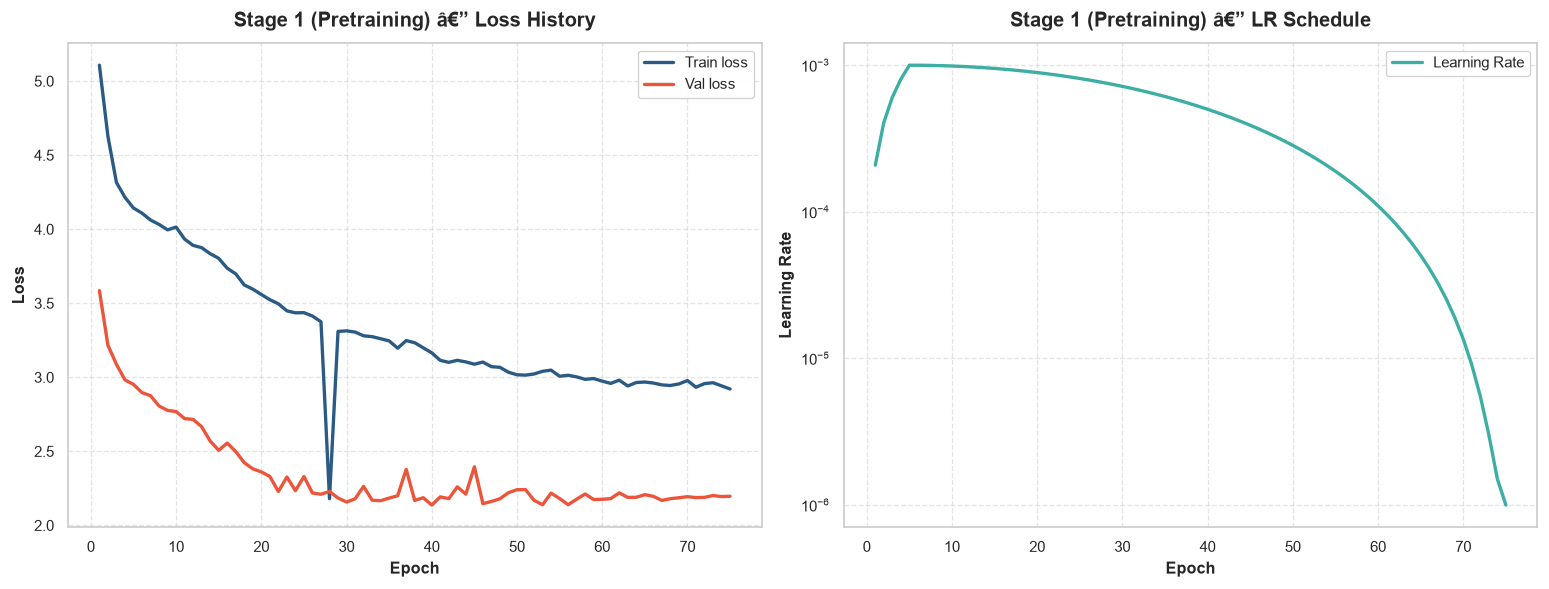

In [16]:
from main import plot_training_history
import matplotlib.pyplot as plt

# Plot Loss & LR curves for Stage 1 (Automatically saves to results/P{x}/.../plots/history_stage_1_pretraining.png)
fig_stage1 = plot_training_history(
    history=result_stage1.history,
    stage="Stage 1 (Pretraining)",
    cfg=notebook_cfg
)
plt.show()


In [17]:
model = build_kg_gt_from_config(
    notebook_cfg, 
    input_dim=true_eeg_dim,
    kin_dim=true_kin_dim,
    edge_prior=edge_prior
).to(device)


In [18]:
# ============================================================================
# Stage 2: Train Full KG-GT Model with Frozen Transformer
# ============================================================================
print("\n--- STAGE 2: GAT Training (Frozen Transformer) ---")

# Load Transformer & NodeProjection weights from Stage 1
best_stage1_state = result_stage1.best_state
if best_stage1_state is not None:
    filtered_state = {k: v for k, v in best_stage1_state.items() if k.startswith("encoder.") or k.startswith("node_projection.")}
    model.load_state_dict(filtered_state, strict=False)
    print("Loaded pretrained Transformer weights into KGGTModel.")


# main.py — replace lines 986-1003
STAGE1_CONVERGED = result_stage1.history['train'][-1] < 0.9 * baseline_mse  # from step 1

for param in model.parameters():
    param.requires_grad = False

for param in model.gat.parameters():
    param.requires_grad = True
for param in model.decoder.parameters():
    param.requires_grad = True
if hasattr(model, "kin_skip_proj") and model.kin_skip_proj is not None:
    for param in model.kin_skip_proj.parameters():
        param.requires_grad = True

if STAGE1_CONVERGED:
    # Encoder learned something real — light touch-up is enough
    for param in model.encoder.layers[-1].parameters():
        param.requires_grad = True
else:
    # Encoder did NOT converge in Stage 1 — freezing most of it would permanently
    # lock in a near-random representation. Open the top-2 layers with a
    # discriminative (smaller) LR instead of just the last one.
    print("[WARNING] Stage 1 did not converge past the mean-baseline — "
          "unfreezing top-2 transformer layers instead of top-1.")
    for layer in model.encoder.layers[-2:]:
        for param in layer.parameters():
            param.requires_grad = True

for param in model.node_projection.parameters():
    param.requires_grad = True

print(f"Active subject: {subject_str}")

# main.py, Stage 2 TrainConfig construction
train_cfg_stage2 = TrainConfig.from_config(
    notebook_cfg["training"],
    max_epochs=notebook_cfg["training"]["max_epochs"],
    lr=notebook_cfg["training"]["stage2_lr"],
)
train_cfg_stage2.warmup_epochs = 0   # keep Stage 2 on plain 'reduce', no warmup

# main.py, right after line 1044
train_cfg_stage2.warmup_epochs = 0
train_cfg_stage2.scheduler = "reduce"        # ADD THIS — undo the global cosine switch for Stage 2
train_cfg_stage2.lr_patience = 5             # keep Stage 2's original tighter patience (it starts from a decent init)
train_cfg_stage2.lr_factor = 0.5             # was 0.05 — same over-aggressive-decay bug applies here too if left unset

# Automatically saves to: outputs/checkpoints_main_stage2/P2
train_cfg_stage2.checkpoint_dir = notebook_cfg["training"].get("checkpoint_dir", "outputs/checkpoints_main") + f"_stage2/{subject_str}"

result_stage2 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    prepare_batch=prepare_batch,
    loss_fn=loss_fn,
    device=device,
    cfg=train_cfg_stage2,
    resume=True,
)


--- STAGE 2: GAT Training (Frozen Transformer) ---
Loaded pretrained Transformer weights into KGGTModel.
[WARNING] Stage 1 did not converge past the mean-baseline — unfreezing top-2 transformer layers instead of top-1.
Active subject: P1
  Differential LR groups:
    GAT/Decoder  : 1.00e-05
    Transformer  : 1.00e-06  (scale=0.1)
    KinSkip      : 3.33e-06  (regularized)

  GPU / Device Status
  OK  Device index    : cuda:0
  OK  GPU name        : NVIDIA GeForce GTX 1660 Ti
  OK  CUDA capability : sm_75
  OK  VRAM (total)    : 6,144 MB
  OK  VRAM allocated  : 1003.6 MB
  OK  VRAM reserved   : 1368.0 MB
  OK  CUDA version    : 12.6
  OK  PyTorch build   : 2.8.0+cu126
  OK  AMP (FP16)      : YES -- Turing tensor cores active
  Optimizer : ADAMW  (weight_decay=0.01)
  Scheduler : REDUCE  (patience=5, factor=0.5)

Resumed from checkpoint: outputs\checkpoints_main_stage2\P1\last.pt
  Completed epochs : 92
  Best val loss    : 1.1988
  Early-stop bad   : 0/50



  Ep   93 [train]:   0%|          | 0/59 [00:00<?, ?batch/s]

  Ep   93 [val  ]:   0%|          | 0/16 [00:00<?, ?batch/s]

  Ep   94 [train]:   0%|          | 0/59 [00:00<?, ?batch/s]

  Ep   94 [val  ]:   0%|          | 0/16 [00:00<?, ?batch/s]

...

  Ep  199 [train]:   0%|          | 0/59 [00:00<?, ?batch/s]

  Ep  199 [val  ]:   0%|          | 0/16 [00:00<?, ?batch/s]

  Ep  200 [train]:   0%|          | 0/59 [00:00<?, ?batch/s]

  Ep  200 [val  ]:   0%|          | 0/16 [00:00<?, ?batch/s]


Training done.  Best val loss = 0.9117
Checkpoints saved to: D:\Research\Interdisciplinary-Schools\Computational-NeuroScience\Team6-2025\outputs\checkpoints_main_stage2\P1


Saved figure:
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\history_stage_2_gat_finetuning.png
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\history_stage_2_gat_finetuning.pdf


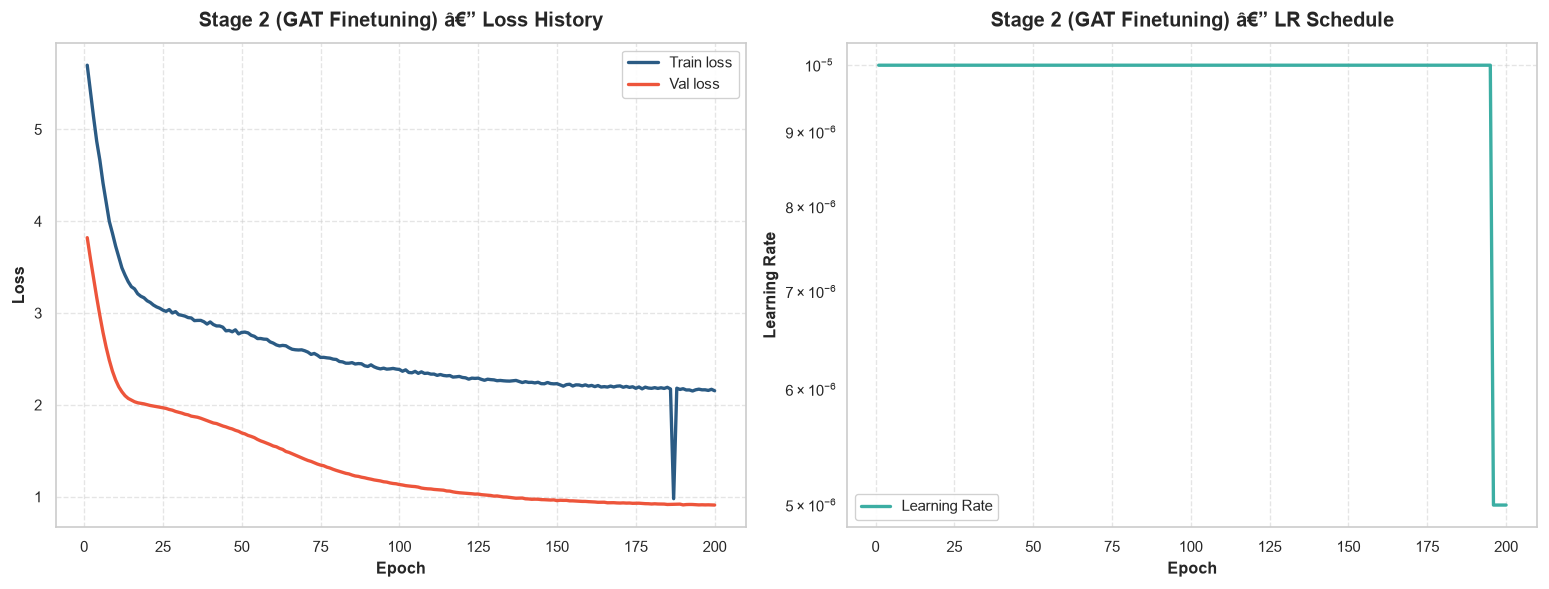

In [19]:
from main import plot_training_history
import matplotlib.pyplot as plt

# Plot Loss & LR curves for Stage 2 (Automatically saves to results/P{x}/.../plots/history_stage_2_gat_finetuning.png)
fig_stage2 = plot_training_history(
    history=result_stage2.history,
    stage="Stage 2 (GAT Finetuning)",
    cfg=notebook_cfg
)
plt.show()


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# EVALUATION — Full metric suite: RMSE, nRMSE, MAE, Pearson r, R^2, VAF
# ─────────────────────────────────────────────────────────────────────────────
import copy, torch
import numpy as np
import pandas as pd
from main import collect_predictions, compute_metrics, load_checkpoint

EMG_NAMES = ["FDI", "APB", "ADM", "ECR", "FCR"]   # adjust to your dataset labels

# Load LAST checkpoint into a fresh copy of the model
best_model = copy.deepcopy(model)

best_ckpt = f"outputs/checkpoints_main_stage2/{subject_str}/best.pt"
print(f"Loading checkpoint from: {best_ckpt}")
load_checkpoint(best_ckpt, best_model, device)


best_model.eval()
# Collect predictions on the held-out test set (stacks all batches)
P_test, Y_test = collect_predictions(
    best_model, test_loader, prepare_batch, device,
    n_channels=len(EMG_NAMES), use_amp=notebook_cfg["training"]["use_amp"],
)
# Compute all 6 metrics (fully vectorised, float64 internally)
metrics = compute_metrics(P_test, Y_test, channel_names=EMG_NAMES)

# Print the publication-ready ASCII table
print("\n" + metrics.as_table() + "\n")

# Pandas DataFrame for export / further analysis
rows = list(zip(
    metrics.channel_names,
    metrics.rmse, metrics.nrmse, metrics.mae,
    metrics.pearson, metrics.r2, metrics.vaf,
))
df = pd.DataFrame(rows,
    columns=["Channel", "RMSE", "nRMSE%", "MAE", "Pearson r", "R^2", "VAF%"])
df.loc["MEAN"] = ["MEAN"] + [df[c].mean() for c in df.columns[1:]]
#display(df.round(4))

# Publication threshold check (VAF > 80% per Winter 1990)
vaf_pass = int((metrics.vaf >= 80.0).sum())
print(f"\nVAF >= 80% threshold: {vaf_pass}/{len(EMG_NAMES)} channels")


Loading checkpoint from: outputs/checkpoints_main_stage2/P1/best.pt
Loaded checkpoint <- outputs/checkpoints_main_stage2/P1/best.pt  (best_val=0.9117)

Channel                RMSE   nRMSE%      MAE  Pearson r      R^2     VAF%
--------------------------------------------------------------------------
FDI                  0.4372     8.00   0.3034     0.9186   0.7969    82.31
APB                  0.5549     6.60   0.3684     0.8520   0.6863    69.22
ADM                  0.8587     6.01   0.5617     0.6429   0.3278    33.32
ECR                  0.3933     7.39   0.2895     0.8454   0.6879    70.28
FCR                  0.7446     6.38   0.4786     0.7912   0.4079    46.38
--------------------------------------------------------------------------
 MEAN                0.5977     6.88   0.4003     0.8100   0.5813    60.30


VAF >= 80% threshold: 1/5 channels


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# INTERPRETABILITY — Dynamic Continuous Window (True Scale)
# ─────────────────────────────────────────────────────────────────────────────
import torch
import numpy as np
import matplotlib.pyplot as plt
from main.plots import plot_interpretability_triptych
from main.plots import plot_kin_skip_over_time
from scipy.signal import butter, sosfiltfilt

# REMOVED "rho_GL" because it is dropped in prepare_batch (now 12 features)
KIN_FEATURE_NAMES = [          
    "p_wrist_x", "p_wrist_y", "p_wrist_z",
    "p_index_x", "p_index_y", "p_index_z",
    "p_thumb_x", "p_thumb_y", "p_thumb_z",
    "d_grip",    "F_L",        "F_G",    
]

# ── TIMELINE SELECTION ────────────────────────────────────────────
start_sec = 0.0   # Start plotting from this second
end_sec   = 10.0  # End plotting at this second
# ──────────────────────────────────────────────────────────────────

fs = CONFIG["data"].get("fs_eeg", 500.0)

# 1. Get the underlying continuous array from the dataset's first series
eeg_full, kin_full, emg_full, block_start_idx = test_ds._windows[0]

# 2. Slice based on the selected seconds
start_idx = block_start_idx + int(start_sec * fs)
end_idx   = block_start_idx + int(end_sec * fs)

raw_eeg = torch.tensor(eeg_full[start_idx : end_idx])
raw_kin = torch.tensor(kin_full[start_idx : end_idx])
raw_emg = torch.tensor(emg_full[start_idx : end_idx])

# 3. Add batch dimension (B=1) and normalize properly via prepare_batch
model_inputs, emg_norm = prepare_batch(
    raw_eeg.unsqueeze(0), 
    raw_kin.unsqueeze(0), 
    raw_emg.unsqueeze(0)
)

eeg_b = model_inputs["eeg"]
kin_b = model_inputs["kin"]
emg_b = emg_norm

# 4. Run the model on the custom time window
best_model.eval()

# Inject visualization temperature to SMOOTHEN the heatmap (Must be > 1.0)
for layer in best_model.encoder.layers:
    layer.mhsa.attention_temperature = 4.0

with torch.no_grad():
    pred_b = best_model(eeg_b, kin_b)

# 5. Convert to numpy and UN-NORMALIZE back to true physical scale
pred_np = pred_b[0].cpu().float().numpy()   
true_np = emg_b[0].cpu().float().numpy()    

emg_mean_np = emg_mean.cpu().numpy()
emg_std_np = emg_std.cpu().numpy()
pred_np = pred_np * emg_std_np + emg_mean_np
true_np = true_np * emg_std_np + emg_mean_np

# ── NEW: Post-processing smoothing (5Hz low-pass filter) ──────────
fs = CONFIG["data"].get("fs_eeg", 500.0)
# sos = butter(4, 5.0 / (fs / 2.0), btype="low", output="sos")
# pred_np = sosfiltfilt(sos, pred_np, axis=0)
# ──────────────────────────────────────────────────────────────────

# 6. Extract EEG temporal attention: (1, H, T, T) -> (H, T, T)

eeg_attn_np = best_model.encoder.layers[-1].mhsa.last_attn_weights[0].cpu().float().numpy()
print(f"Raw EEG attention shape: {eeg_attn_np.shape}  (H, T, T)")

from scipy.ndimage import gaussian_filter1d

eeg_attn_np = gaussian_filter1d(eeg_attn_np, sigma=3.0, axis=-1)

# 7. Extract dynamic kinematic edge bias
if hasattr(best_model.gat, "last_kin_edge_bias"):
    kin_edge_np = best_model.gat.last_kin_edge_bias[0].cpu().float().numpy()
    print(f"Kinematic edge bias shape: {kin_edge_np.shape}  (T, H, N, N)")
else:
    raise RuntimeError("last_kin_edge_bias not found. Set use_kinematic_guidance=True.")

# 8. Generate the 3-panel interpretability money plot
fig = plot_interpretability_triptych(
    pred=pred_np,
    target=true_np,
    eeg_attn=eeg_attn_np,
    kin_edge_bias=kin_edge_np,
    muscle_names=EMG_NAMES,
    kin_feature_names=KIN_FEATURE_NAMES,
    fs=fs,
    smooth_hz  = 5.0,
    cfg=CONFIG,
)

# ── DIAGNOSTIC: Kinematic Skip Highway Activation vs EMG ──────────────────

from main.plots import plot_kin_skip_over_time

fig = plot_kin_skip_over_time(
    model      = best_model,
    eeg_window = eeg_b,
    kin_window = kin_b,
    emg_target = true_np,     # physical scale
    emg_mean   = emg_mean,
    emg_std    = emg_std,
    smooth_hz  = 5.0,        # ← low-pass at 10 Hz; set None to disable
    emg_names  = EMG_NAMES,
    fs         = fs,
    cfg        = CONFIG,
)
plt.show()


RuntimeError: [enforce fail at alloc_cpu.cpp:121] data. DefaultCPUAllocator: not enough memory: you tried to allocate 800000000 bytes.

Saved figure:
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\residual_decomposition.png
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\residual_decomposition.pdf


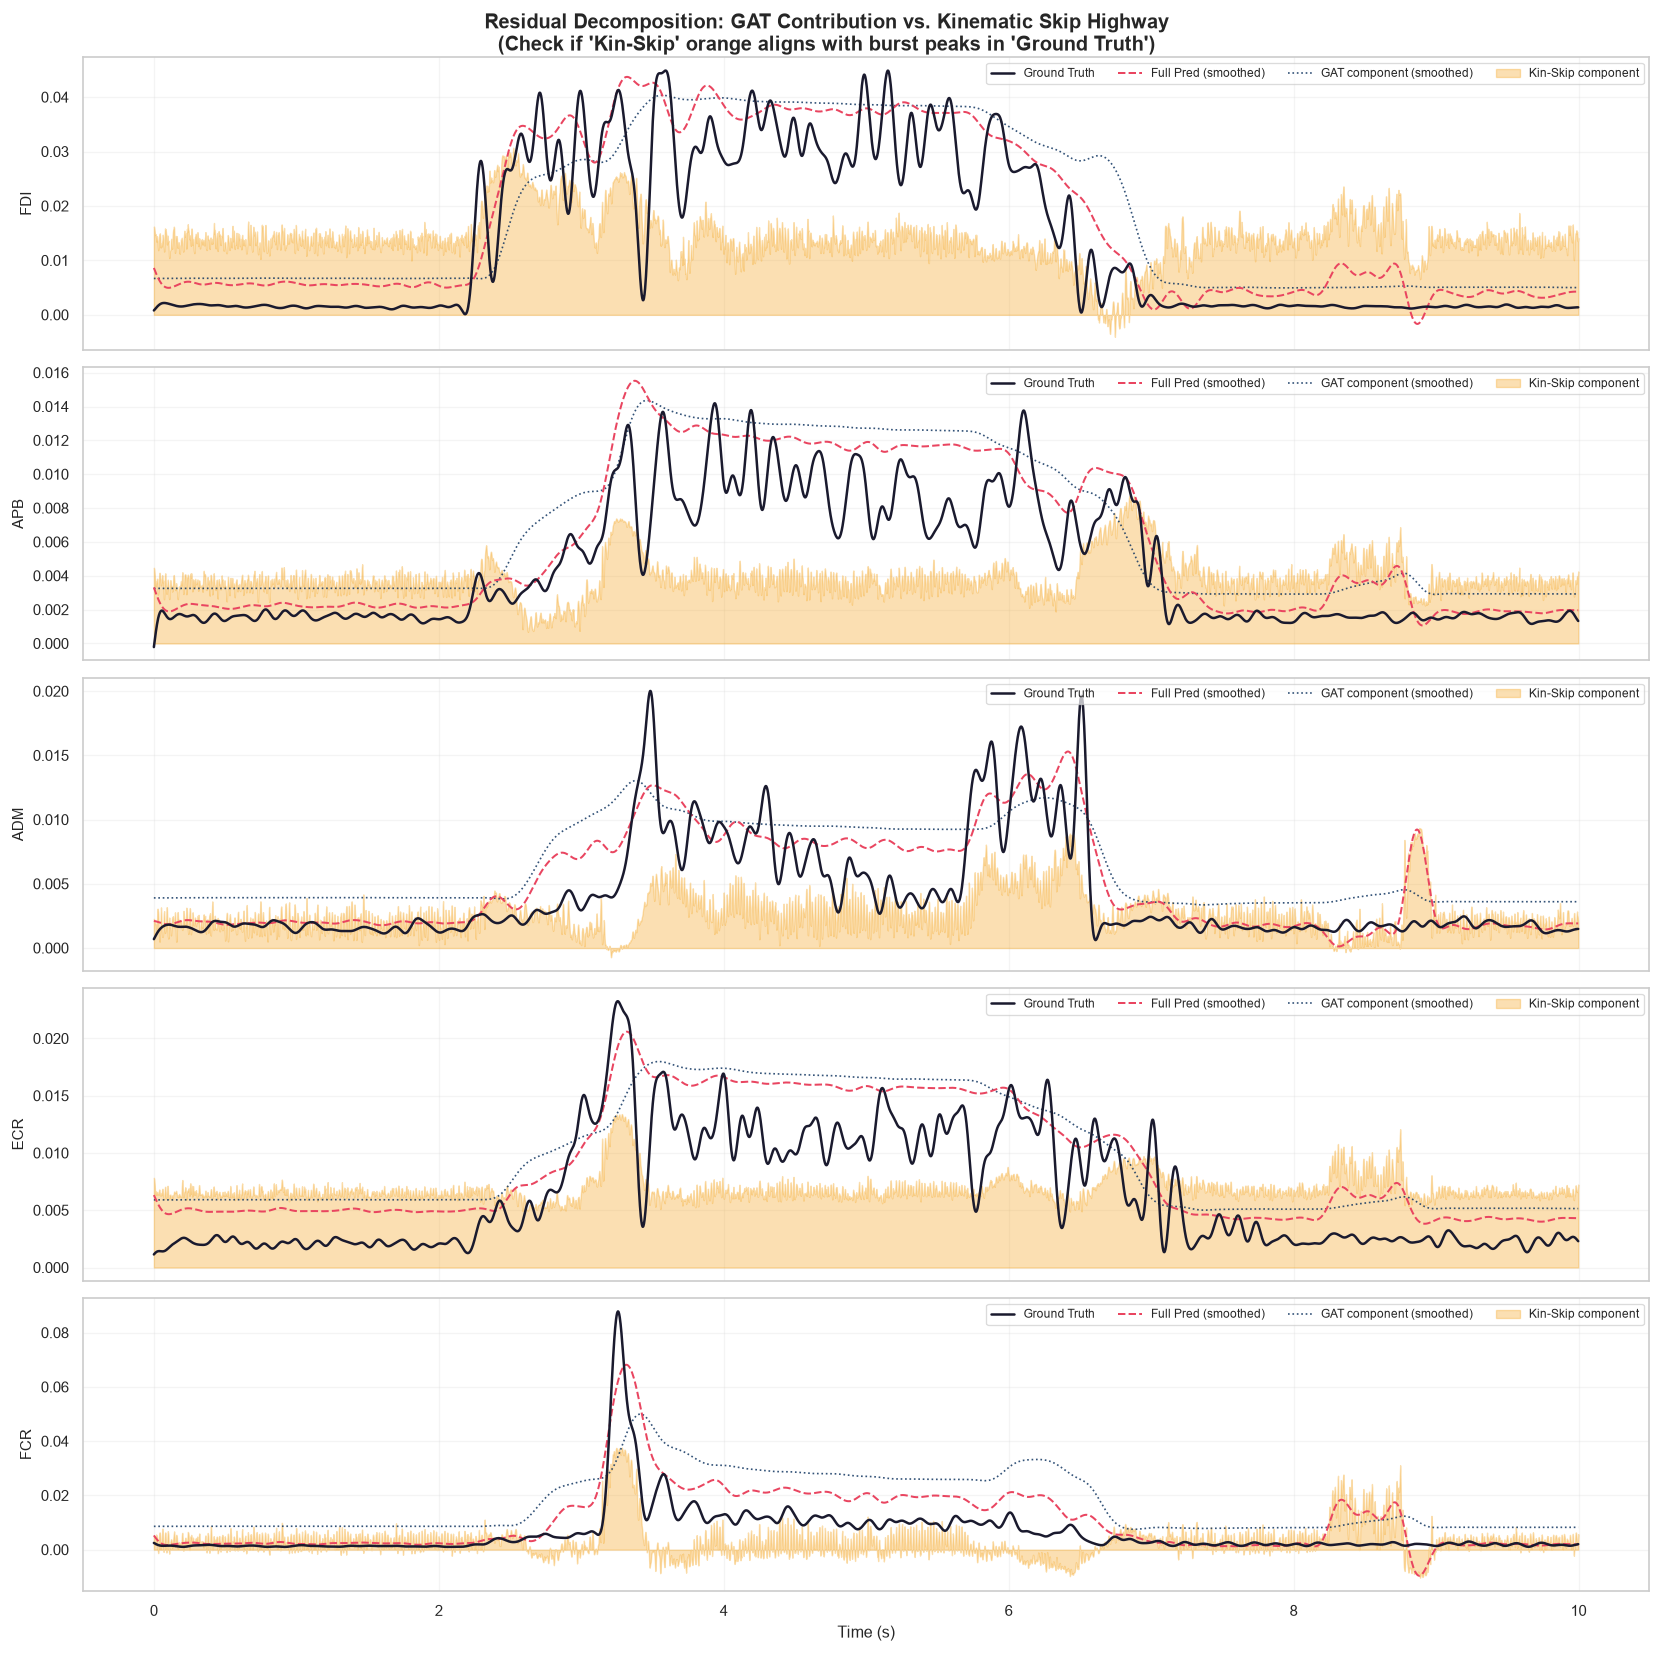

In [ ]:
# ── DIAGNOSTIC: Residual Decomposition (GAT vs Kinematic Skip) ────────────
from main.plots import plot_residual_decomposition

fig = plot_residual_decomposition(
    model      = best_model,
    eeg_window = eeg_b,          # Tensor (1, T, 32)
    kin_window = kin_b,          # Tensor (1, T, 13)
    emg_target = true_np,        # np.ndarray (T, 5) — physical scale
    emg_mean   = emg_mean,       # ← NEW: un-normalizes model outputs to physical scale
    emg_std    = emg_std,        # ← NEW
    smooth_hz  = 5.0,           # optional low-pass Hz (set None to disable smoothing)
    emg_names  = EMG_NAMES,
    fs         = fs,
    cfg        = CONFIG,
)
plt.show()


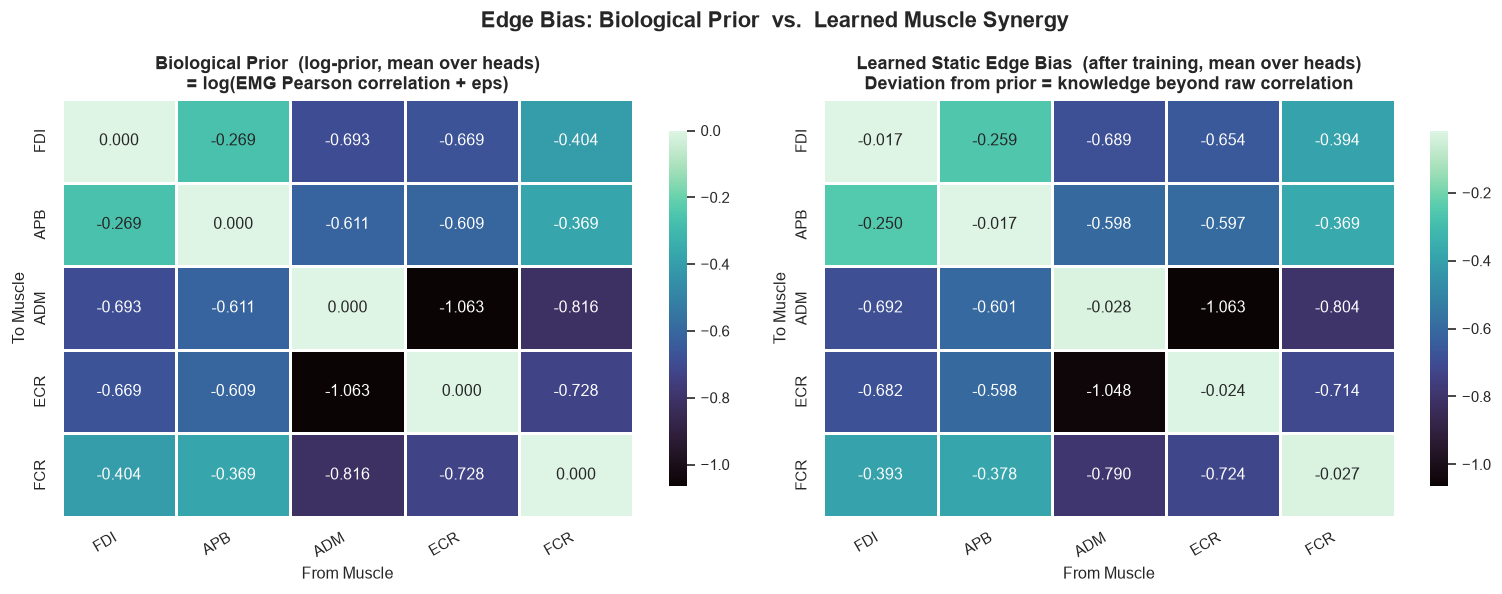

findfont: Failed to find font weight semibold, now using 700.


Saved figure:
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\muscle_synergy_matrix.png
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\muscle_synergy_matrix.pdf


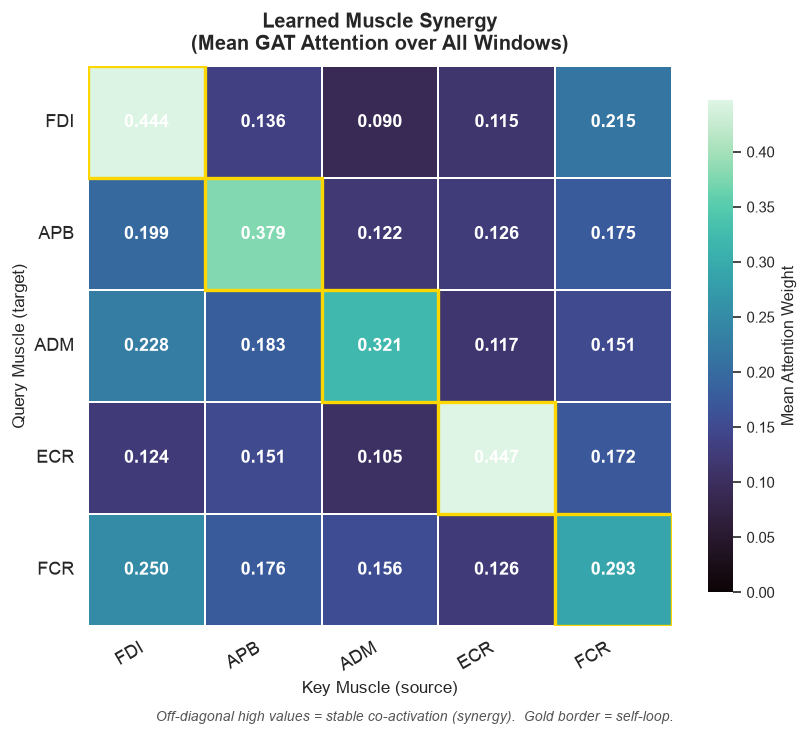

Saved figure:
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\channel_correlation_matrix.png
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\channel_correlation_matrix.pdf


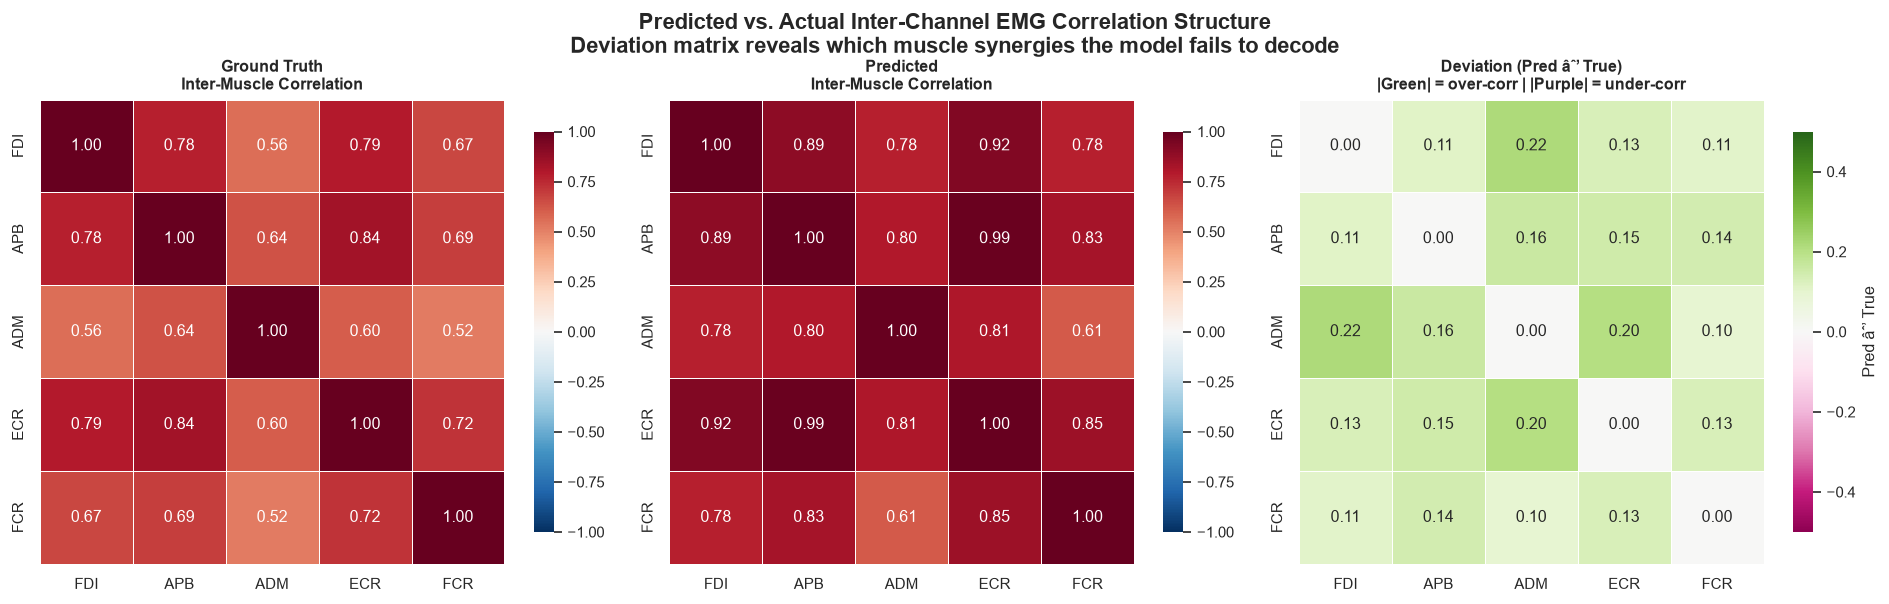

Saved figure:
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\emg_error_analysis.png
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\emg_error_analysis.pdf


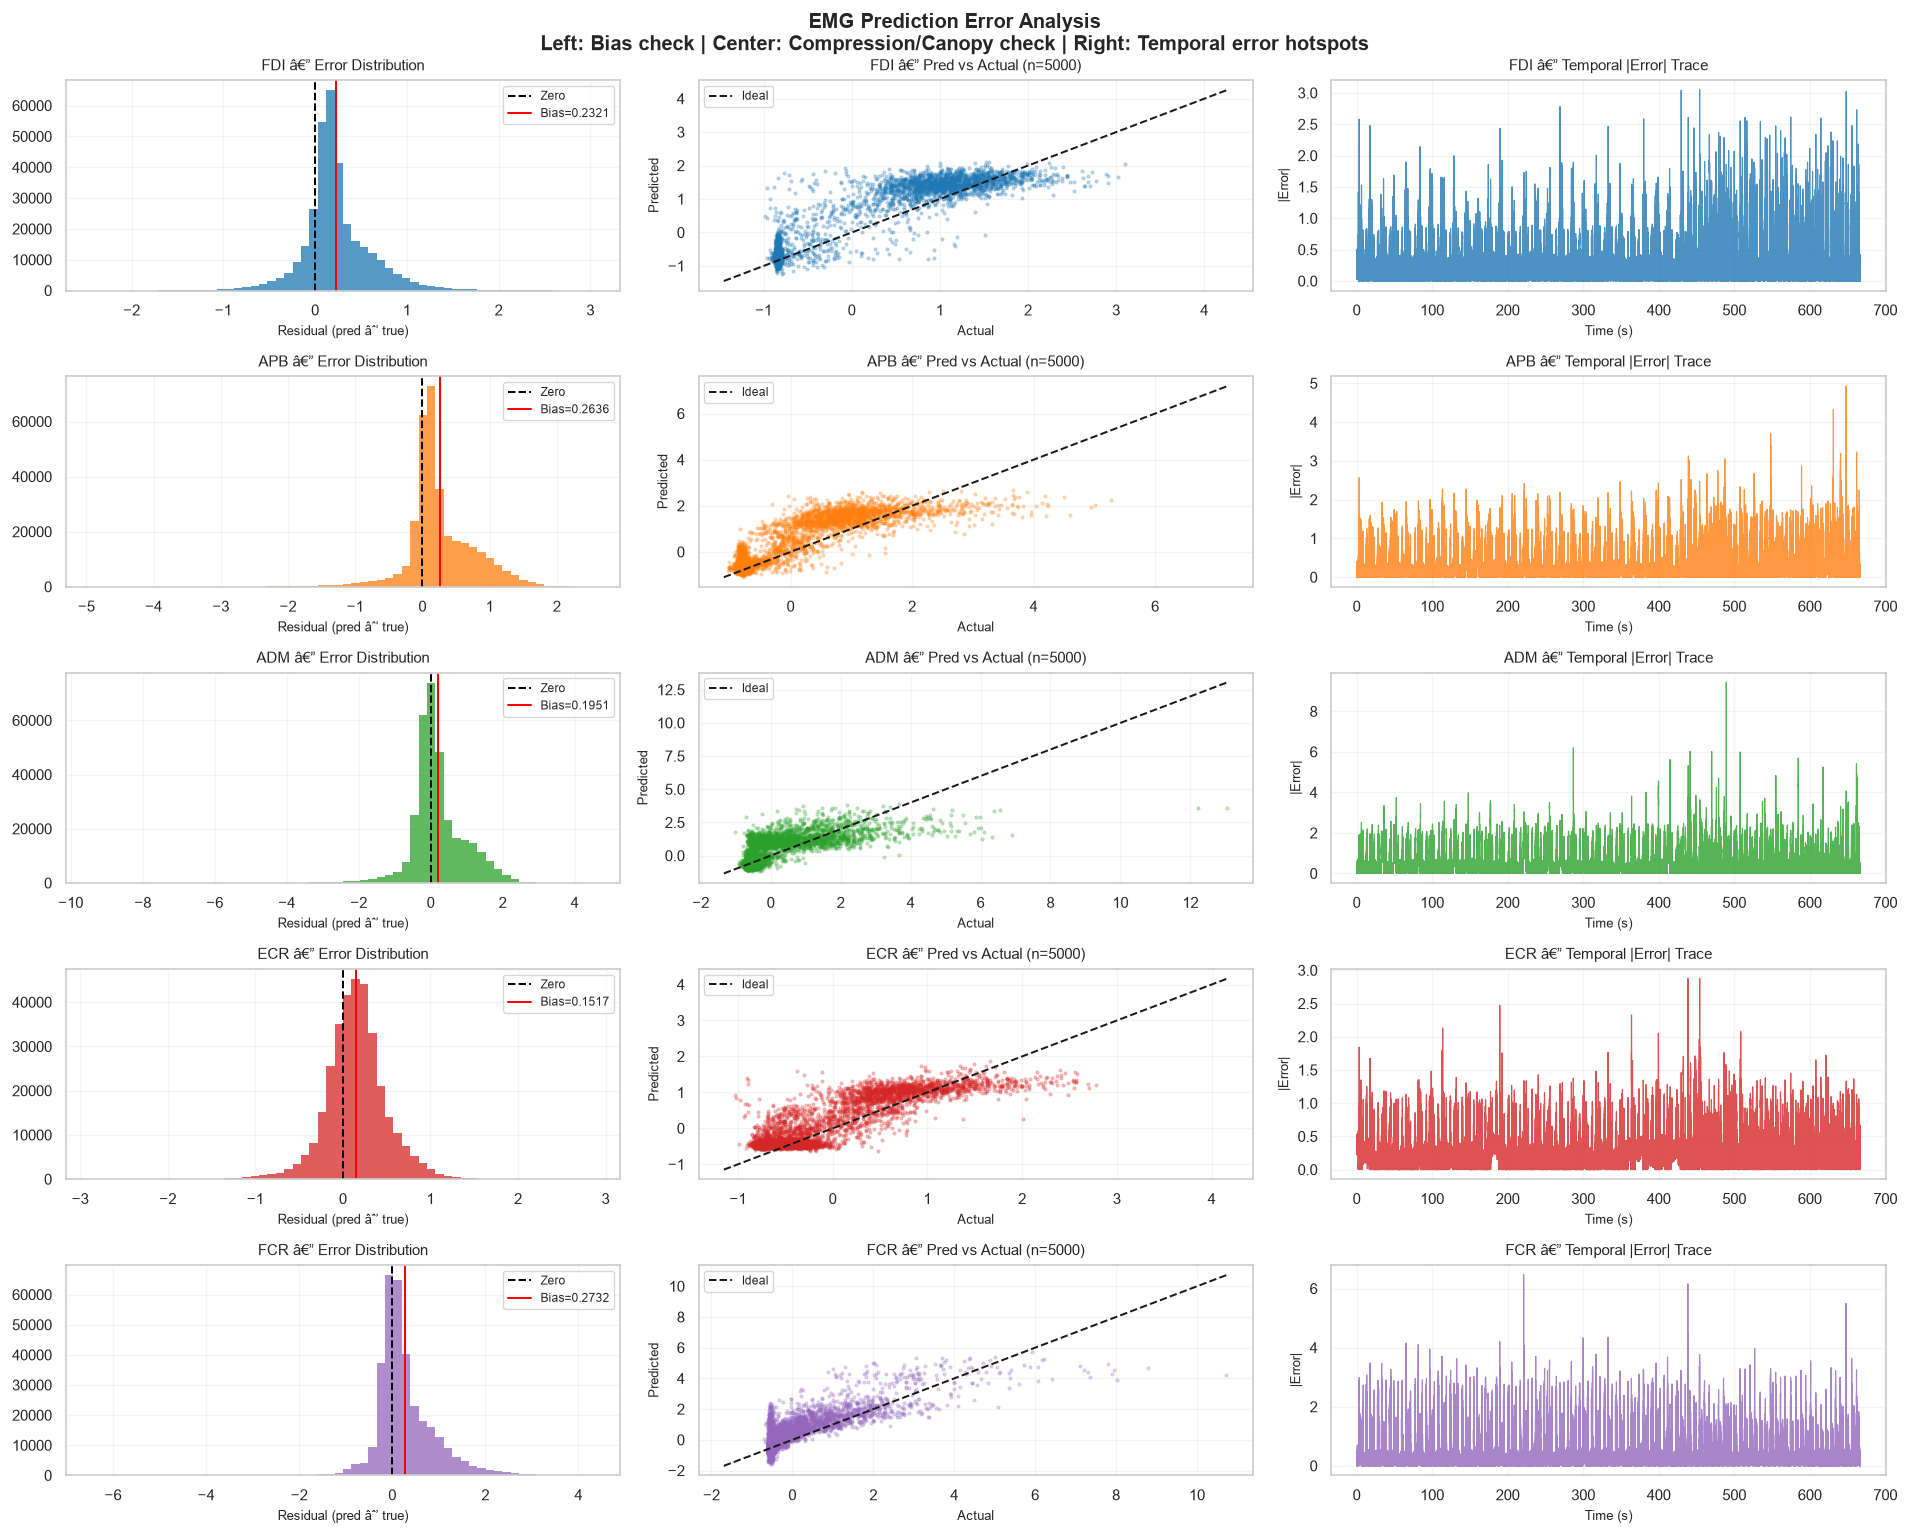

Saved figure:
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\kin_edge_linear_weights.png
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\kin_edge_linear_weights.pdf


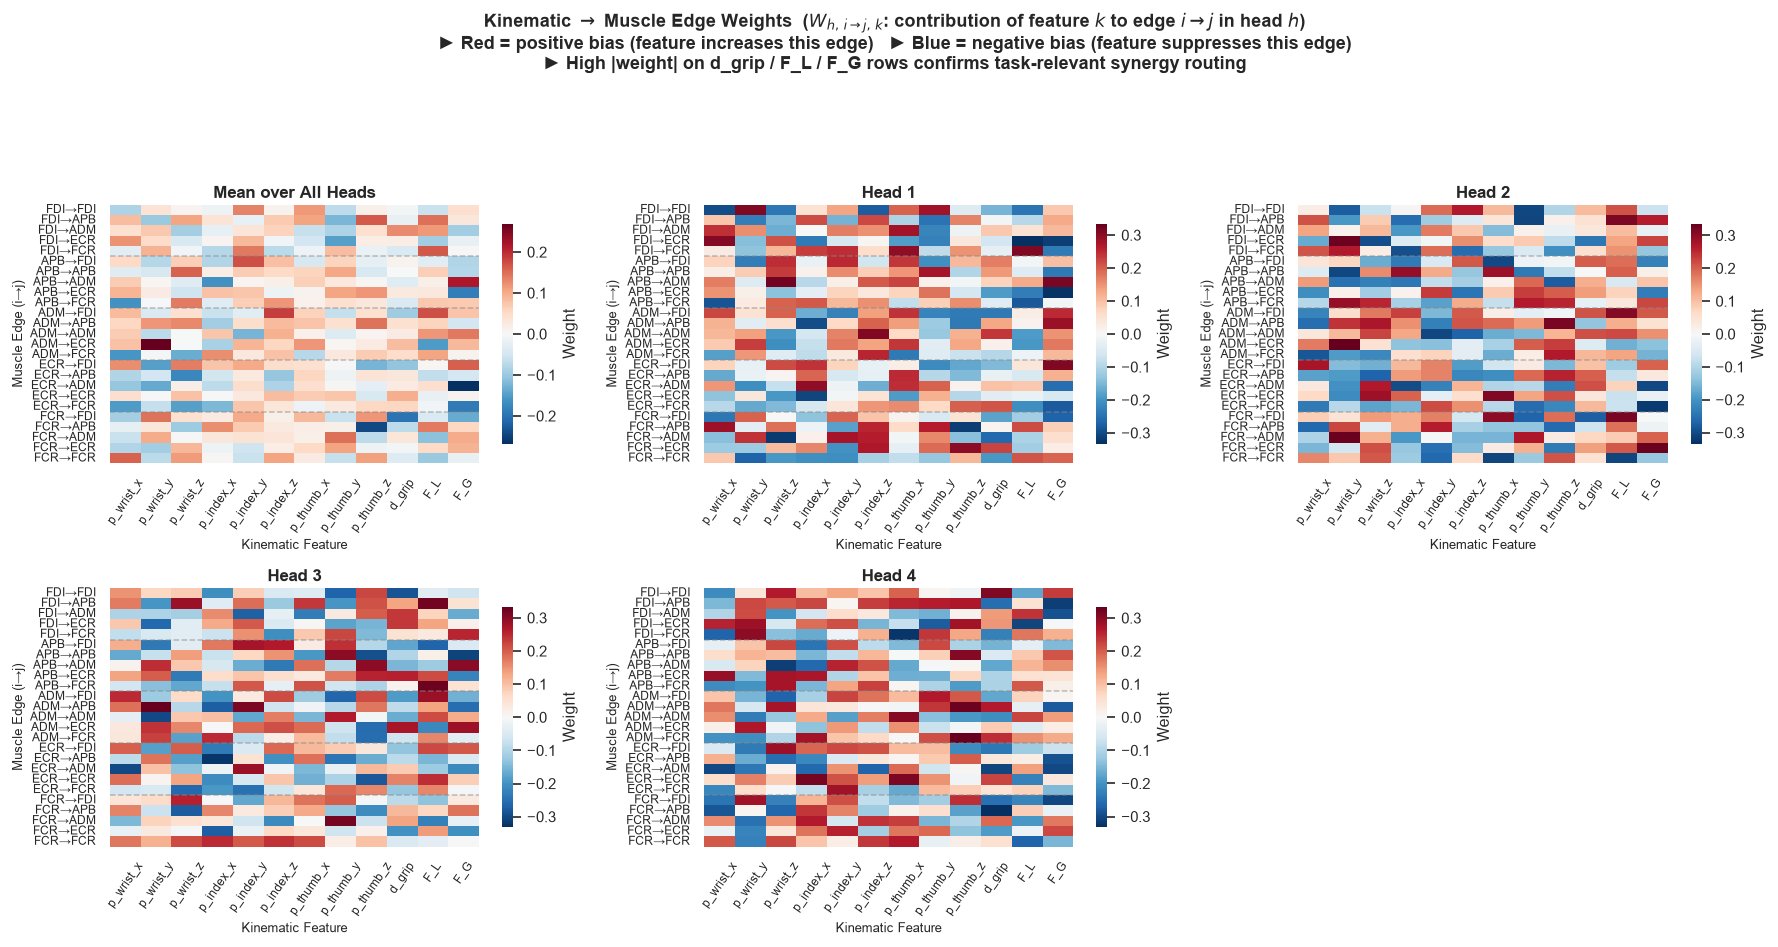


Inspect high |weight| rows on d_grip / F_L / F_G for key insights.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# STATIC EDGE BIAS + MUSCLE SYNERGY MATRIX + KINEMATIC WEIGHT HEATMAP
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from main import plot_muscle_synergy_matrix, plot_kin_edge_linear_weights

# ── 1. Biological prior vs. learned static edge bias ──────────────────────
gat = best_model.gat
learned_bias = gat.edge_bias.detach().cpu().numpy()    # (H, N, N)
prior_anchor  = gat.edge_prior_anchor.cpu().numpy()    # (H, N, N)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor="white")
kw = dict(
    annot=True, fmt=".3f", cmap="mako",
    xticklabels=EMG_NAMES, yticklabels=EMG_NAMES,
    cbar_kws={"shrink": 0.85}, linewidths=0.8, linecolor="white",
)
sns.heatmap(prior_anchor.mean(0), ax=axes[0], **kw)
axes[0].set_title(
    "Biological Prior  (log-prior, mean over heads)\n"
    "= log(EMG Pearson correlation + eps)", fontsize=11, fontweight="bold"
)
axes[0].set_xlabel("From Muscle"); axes[0].set_ylabel("To Muscle")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right")

sns.heatmap(learned_bias.mean(0), ax=axes[1], **kw)
axes[1].set_title(
    "Learned Static Edge Bias  (after training, mean over heads)\n"
    "Deviation from prior = knowledge beyond raw correlation",
    fontsize=11, fontweight="bold",
)
axes[1].set_xlabel("From Muscle"); axes[1].set_ylabel("To Muscle")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right")

plt.suptitle(
    "Edge Bias: Biological Prior  vs.  Learned Muscle Synergy",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.show()

# ── 2. GAT attention synergy matrix (full test set) ───────────────────────
all_attn = []
best_model.eval()
with torch.no_grad():
    for raw_eeg, raw_kin, raw_emg in test_loader:
        # IMPORTANT: Pass through prepare_batch to drop rho_GL (13->12) and normalize!
        model_inputs, _ = prepare_batch(raw_eeg, raw_kin, raw_emg)
        
        # Now pass the properly processed inputs to the model
        best_model(
            model_inputs["eeg"],
            model_inputs["kin"],
        )
        if hasattr(best_model.gat, "last_attn_weights"):
            all_attn.append(best_model.gat.last_attn_weights.cpu().numpy())

if all_attn:
    all_attn_np = np.concatenate(all_attn, axis=0)   # (B*T, H, N, N)
    fig_syn = plot_muscle_synergy_matrix(all_attn_np, EMG_NAMES, cfg=CONFIG)
    plt.show()

# ── DIAGNOSTIC: Predicted vs Actual Inter-Muscle Correlation ──────────────
from main.plots import plot_channel_correlation_matrix

# Collect all predictions and targets from the test loader
all_preds_list, all_targets_list = [], []
best_model.eval()
with torch.no_grad():
    for raw_eeg, raw_kin, raw_emg in test_loader:
        model_inputs, emg_norm = prepare_batch(raw_eeg, raw_kin, raw_emg)
        pred = best_model(model_inputs["eeg"], model_inputs["kin"])
        all_preds_list.append(pred.cpu().float().numpy())
        all_targets_list.append(emg_norm.cpu().float().numpy())

all_preds_flat   = np.concatenate(all_preds_list,   axis=0).reshape(-1, len(EMG_NAMES))
all_targets_flat = np.concatenate(all_targets_list, axis=0).reshape(-1, len(EMG_NAMES))

fig = plot_channel_correlation_matrix(
    y_pred     = all_preds_flat,
    y_true     = all_targets_flat,
    emg_names  = EMG_NAMES,
    cfg        = CONFIG,
)
plt.show()

# ── DIAGNOSTIC: EMG Error Analysis (Bias / Canopy / Temporal Hotspots) ────
from main.plots import plot_emg_error_analysis

fig = plot_emg_error_analysis(
    y_pred    = all_preds_flat,
    y_true    = all_targets_flat,
    emg_names = EMG_NAMES,
    fs        = fs,
    cfg       = CONFIG,
)
plt.show()



# ── 3. Transparent kinematic -> edge weight matrix ────────────────────────
if hasattr(best_model.gat, "kin_edge_linear"):
    W = best_model.gat.kin_edge_linear.weight.detach().cpu().numpy()
    gat_cfg = CONFIG["model"]["gat"]
    fig_kin = plot_kin_edge_linear_weights(
        weight_matrix=W,
        muscle_names=EMG_NAMES,                       
        kin_feature_names=KIN_FEATURE_NAMES,
        num_heads=gat_cfg["heads"],
        n_nodes=5,
        cfg=CONFIG,
    )
    plt.show()
    print("\nInspect high |weight| rows on d_grip / F_L / F_G for key insights.")
else:
    print("kin_edge_linear not found (use_kinematic_guidance may be False).")


Generating Plot 1: Neural-Mechanical Latency Lag Analysis...
Saved figure:
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\neural_mechanical_latency_lag.png
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\neural_mechanical_latency_lag.pdf


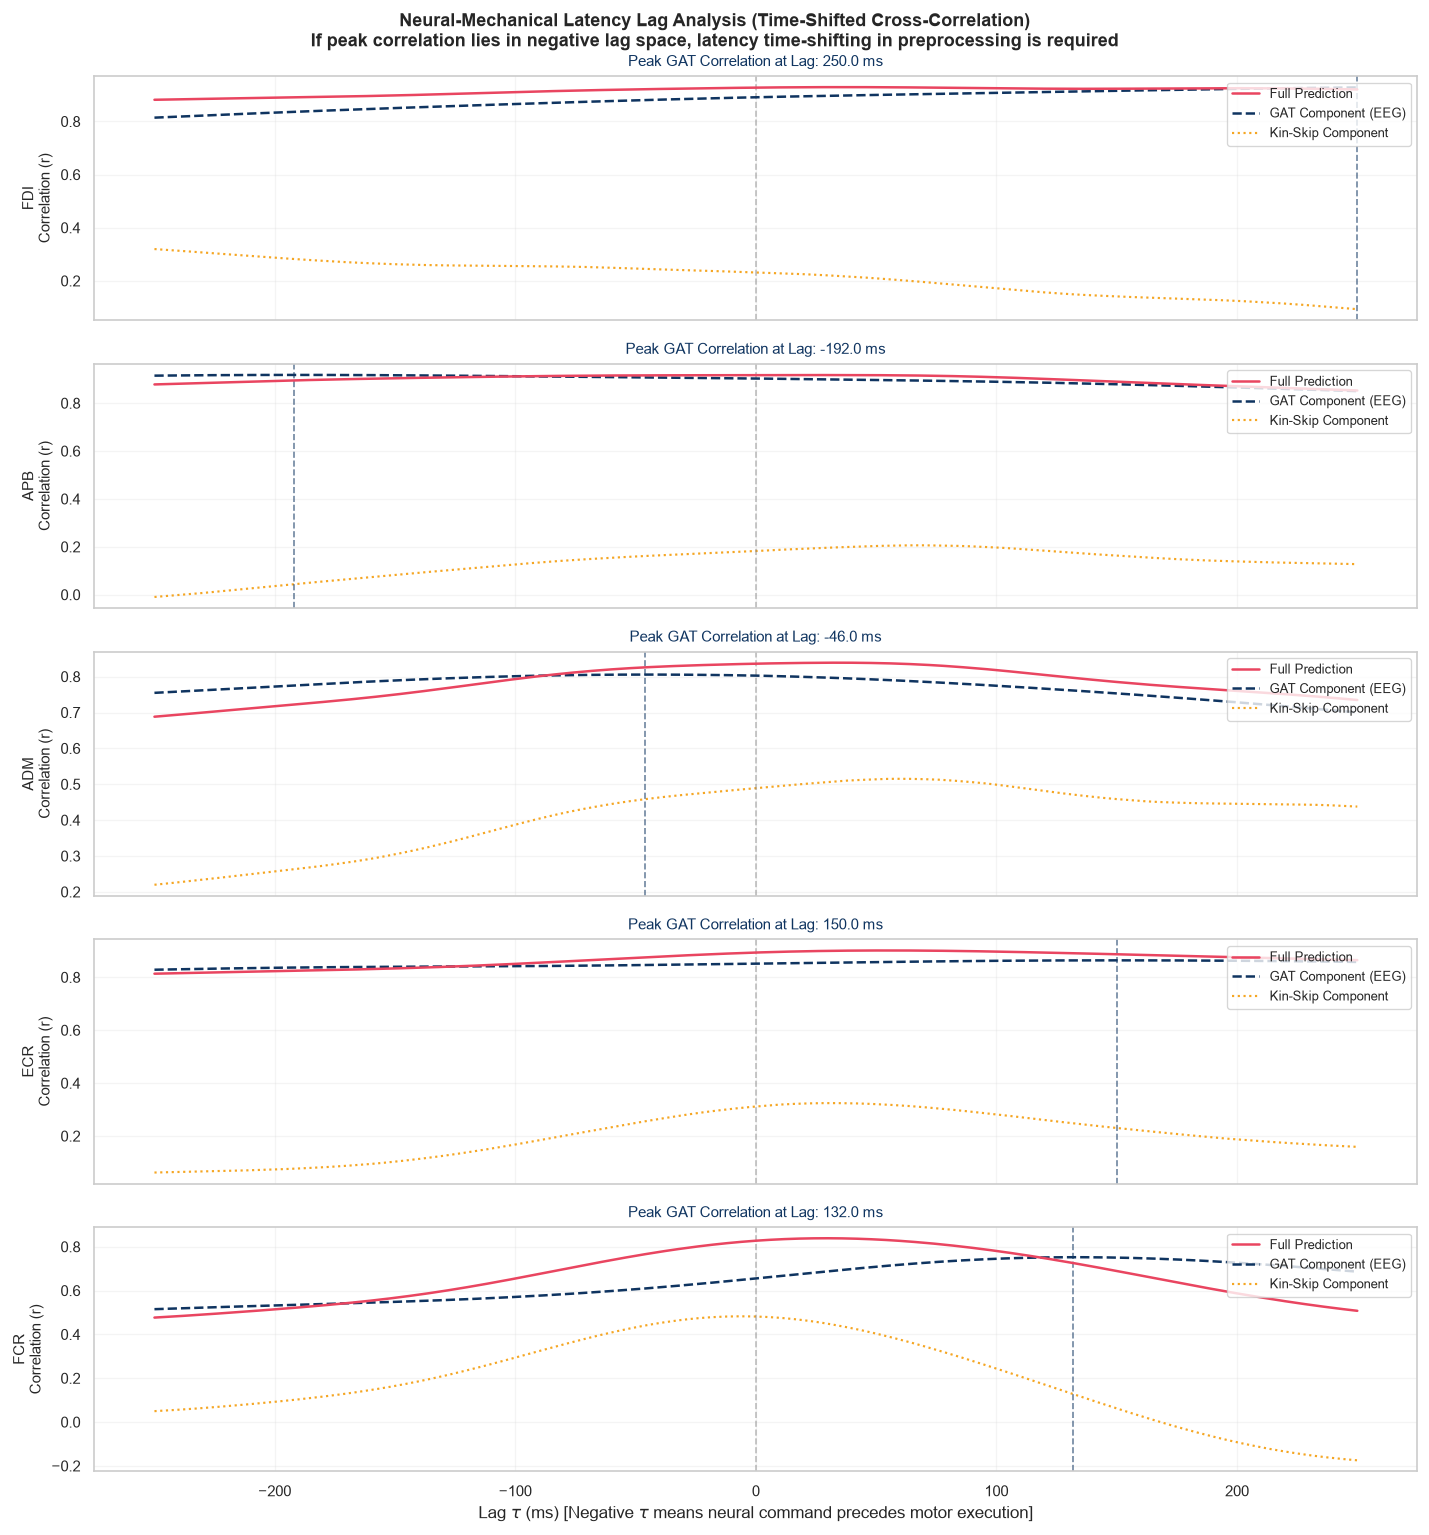


Generating Plot 2: Spectral Power Decomposition (Welch's PSD)...
Saved figure:
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\spectral_power_decomposition.png
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\spectral_power_decomposition.pdf


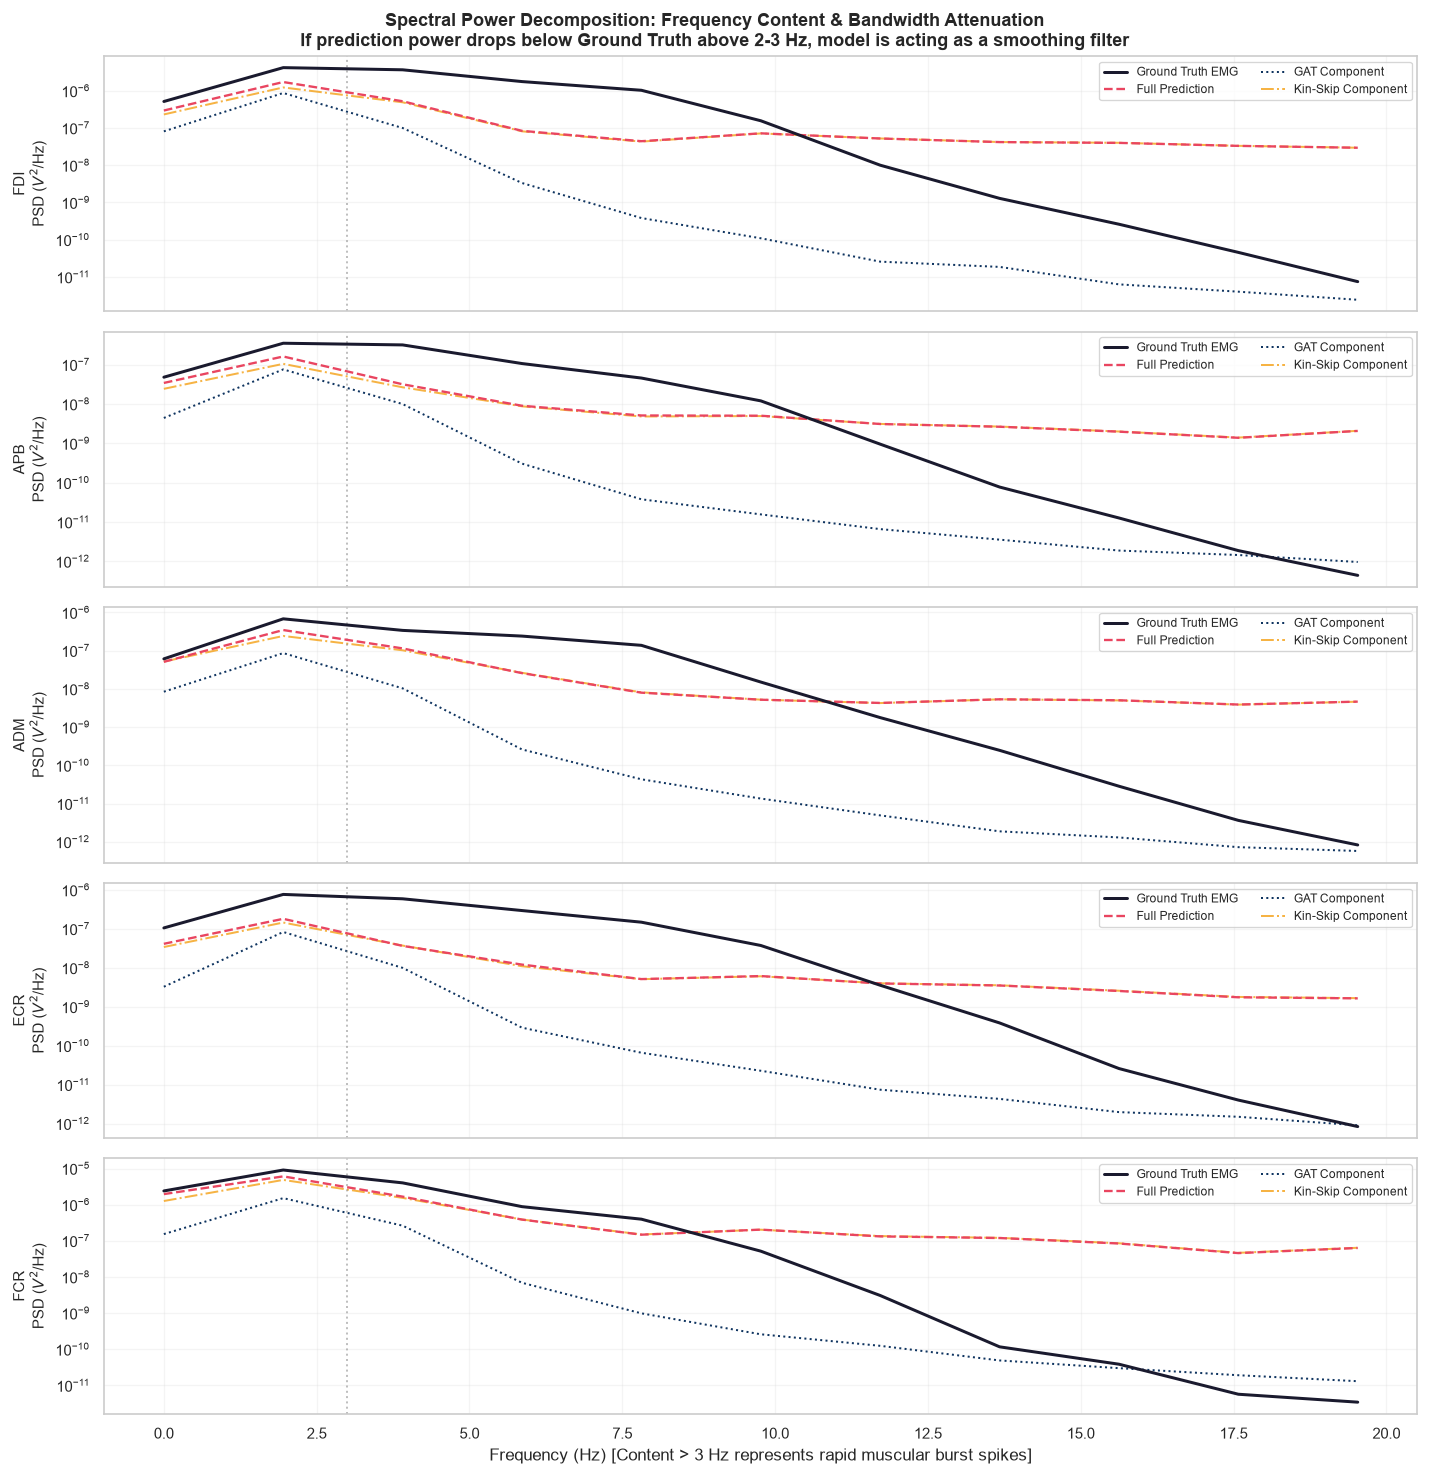


Generating Plot 3: Kinematic State Separation Density Grid...
Saved figure:
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\kinematic_velocity_acceleration_density.png
  results\P1\main\ep200_st500_lr1e-05_bs32\plots\kinematic_velocity_acceleration_density.pdf


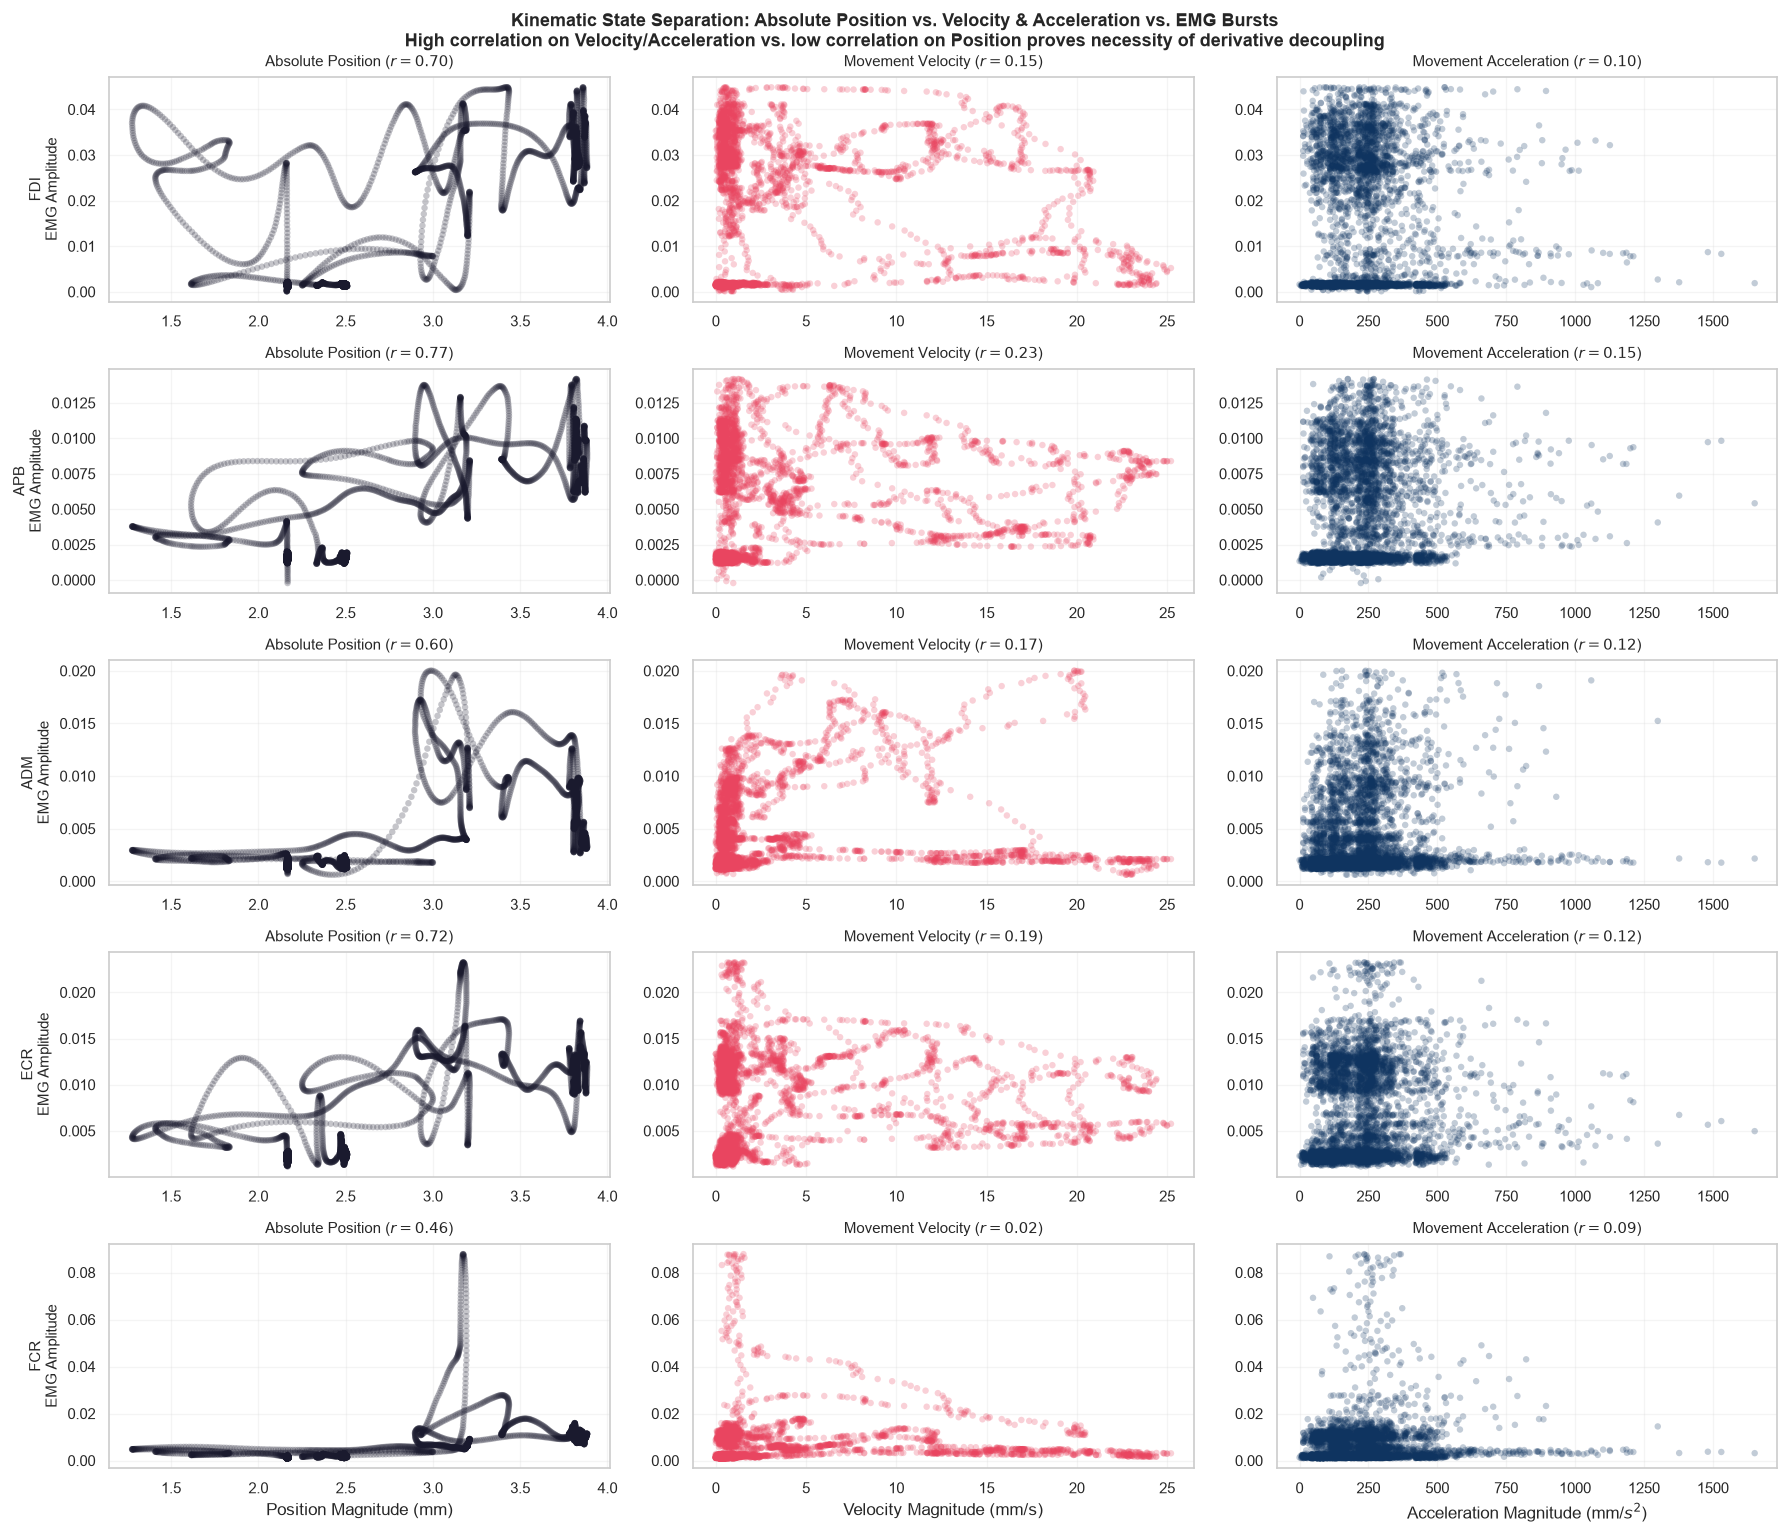

In [ ]:
import matplotlib.pyplot as plt
from main import (
    plot_neural_mechanical_latency_lag,
    plot_spectral_power_decomposition,
    plot_kinematic_velocity_acceleration_density,
)

best_model.eval()

# ── PLOT 1: Neural-Mechanical Latency Lag (Time-Shifted Cross-Correlation) ──
print("Generating Plot 1: Neural-Mechanical Latency Lag Analysis...")
fig_lat = plot_neural_mechanical_latency_lag(
    model=best_model,
    eeg_window=eeg_b,               # model_inputs["eeg"], shape: (1, T, 32)
    kin_window=kin_b,               # model_inputs["kin"], shape: (1, T, 12)
    emg_target=true_np,             # un-normalized ground truth array, shape: (T, 5)
    emg_names=EMG_NAMES,
    fs=500,
    max_lag_ms=250,                 # check delays from -250ms to +250ms
    emg_mean=emg_mean,              # un-normalize internal components to match true_np
    emg_std=emg_std,
    cfg=CONFIG
)
plt.show()

# ── PLOT 2: Spectral Power Decomposition (PSD Bandwidth & Canopy Check) ──
print("\nGenerating Plot 2: Spectral Power Decomposition (Welch's PSD)...")
fig_spec = plot_spectral_power_decomposition(
    model=best_model,
    eeg_window=eeg_b,
    kin_window=kin_b,
    emg_target=true_np,
    emg_names=EMG_NAMES,
    fs=500,
    max_freq_hz=20.0,
    emg_mean=emg_mean,
    emg_std=emg_std,
    cfg=CONFIG
)
plt.show()

# ── PLOT 3: Kinematic Velocity & Acceleration Density Alignment ──
print("\nGenerating Plot 3: Kinematic State Separation Density Grid...")
fig_kin_dens = plot_kinematic_velocity_acceleration_density(
    kin_window=kin_b,               # shape: (1, T, 12) or (T, 12)
    emg_target=true_np,
    emg_names=EMG_NAMES,
    fs=500,
    cfg=CONFIG
)
plt.show()


In [ ]:
# ============================================================================
# [LOSOCV ONLY] Advance to the next fold
# ============================================================================
# When running LOSOCV, run this cell to advance to the next held-out subject,
# then re-run cells B through Q to train & evaluate that fold.
# ─────────────────────────────────────────────────────────────────────────────
if is_losocv:
    # Find current fold index and advance
    _current_idx = participant_list.index(p_test)
    _next_idx = _current_idx + 1
    if _next_idx < len(participant_list):
        p_test = participant_list[_next_idx]
        train_participants = [p for p in participant_list if p != p_test]
        test_participants  = [p_test]
        subject_str = f"LOSO_P{p_test}"
        print(f"Advanced to fold {_next_idx + 1}/{len(participant_list)}: Test = P{p_test}")
        print(f"  Train participants : {train_participants}")
    else:
        print("All LOSOCV folds completed!")
else:
    print("Not in LOSOCV mode — this cell is a no-op.")


Not in LOSOCV mode — this cell is a no-op.
